# 0 - IMPORTS

In [2]:
import pickle
import optuna
import inflection
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from boruta import BorutaPy
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OrdinalEncoder, TargetEncoder, StandardScaler

## 0.1 Helper Functions

In [3]:
def vscode_settings():
    plt.style.use('bmh')
    
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 14
    
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option('display.expand_frame_repr', False)
    
    sns.set_palette("Set2")  # ou "Set2", "deep", "colorblind"

vscode_settings()

# GRAFICO CUMULATIVO - MODELOS
def cumulative_gain(df, score_col='score', target_col='response', n_bins=10):
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    df['bin'] = pd.qcut(df.index, q=n_bins, labels=False)
    
    gain = (
        df.groupby('bin')[target_col]
        .sum()
        .cumsum()
        / df[target_col].sum()
    )
    
    return gain

def get_x_axis(cg):
    n = len(cg)
    return np.linspace(1/n, 1, n)


def annotate_points(ax, x, cg, points=[0.1, 0.2, 0.3]):
    for p in points:
        idx = int(p * len(cg)) - 1
        y = cg.values[idx] * 100

        ax.annotate(
            f'{int(p*100)}% → {y:.1f}%',
            xy=(x[idx], cg.values[idx]),
            xytext=(0, 8),
            textcoords='offset points',
            ha='center',
            fontsize=15,
            fontweight='bold'
        )


## 0.2 Load Data

In [4]:
df_raw = pd.read_csv('../data/train.csv')

In [5]:
df_raw.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


# 1 - DATA DESCRIPTION

In [6]:
df1 = df_raw.copy()

## 1.1 Rename/Adjust columns

In [7]:
cols_old = df1.columns

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase, cols_old))

df1.columns = cols_new
df1.columns

Index(['id', 'gender', 'age', 'driving_license', 'region_code',
       'previously_insured', 'vehicle_age', 'vehicle_damage', 'annual_premium',
       'policy_sales_channel', 'vintage', 'response'],
      dtype='object')

## 1.2 Data Dimensions

In [8]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Cols: {}'.format(df1.shape[1]))

Number of Rows: 381109
Number of Cols: 12


## 1.3 Data Types

In [9]:
df1.dtypes

id                        int64
gender                   object
age                       int64
driving_license           int64
region_code             float64
previously_insured        int64
vehicle_age              object
vehicle_damage           object
annual_premium          float64
policy_sales_channel    float64
vintage                   int64
response                  int64
dtype: object

## 1.4 Confirm NA

In [10]:
df1.isna().sum()

id                      0
gender                  0
age                     0
driving_license         0
region_code             0
previously_insured      0
vehicle_age             0
vehicle_damage          0
annual_premium          0
policy_sales_channel    0
vintage                 0
response                0
dtype: int64

## 1.5 Descriptive Statistical

In [11]:
num_attributes = df1.select_dtypes( include=['int64', 'float64'])
cat_attributes = df1.select_dtypes( exclude=['int64', 'float64'])

In [12]:
num_attributes.head()

,id,age,driving_license,region_code,previously_insured,annual_premium,policy_sales_channel,vintage,response
0,1,44,1,28.0,0,40454.0,26.0,217,1
1,2,76,1,3.0,0,33536.0,26.0,183,0
2,3,47,1,28.0,0,38294.0,26.0,27,1
3,4,21,1,11.0,1,28619.0,152.0,203,0
4,5,29,1,41.0,1,27496.0,152.0,39,0


In [13]:
cat_attributes.head()

,gender,vehicle_age,vehicle_damage
0,Male,> 2 Years,Yes
1,Male,1-2 Year,No
2,Male,> 2 Years,Yes
3,Male,< 1 Year,No
4,Female,< 1 Year,No


### 1.5.1 Numerical attributes

In [14]:
# Central Tendency - mean, median
ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew, kurtosis
d1 = pd.DataFrame(num_attributes.apply(np.std)).T
d2 = pd.DataFrame(num_attributes.apply(min)).T
d3 = pd.DataFrame(num_attributes.apply(max)).T
d4 = pd.DataFrame(num_attributes.apply( lambda x: x.max() - x.min())).T
d5 = pd.DataFrame(num_attributes.apply( lambda x: x.skew())).T
d6 = pd.DataFrame(num_attributes.apply( lambda x: x.kurtosis())).T

# concatenate

m = pd.concat([d2,d3,d4,ct1,ct2,d1,d5,d6]).T.reset_index()
m.columns = ['attributes','min','max','range','mean','median','std','skew','kurtosis']

m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,id,1.0,381109.0,381108.0,190555.000000,190555.0,110016.691870,9.443274e-16,-1.200000
1,age,20.0,85.0,65.0,38.822584,36.0,15.511591,6.725390e-01,-0.565655
2,driving_license,0.0,1.0,1.0,0.997869,1.0,0.046109,-2.159518e+01,464.354302
3,region_code,0.0,52.0,52.0,26.388807,28.0,13.229871,-1.152664e-01,-0.867857
4,previously_insured,0.0,1.0,1.0,0.458210,0.0,0.498251,1.677471e-01,-1.971871
5,annual_premium,2630.0,540165.0,537535.0,30564.389581,31669.0,17213.132474,1.766087e+00,34.004569
6,policy_sales_channel,1.0,163.0,162.0,112.034295,133.0,54.203924,-9.000081e-01,-0.970810
7,vintage,10.0,299.0,289.0,154.347397,154.0,83.671194,3.029517e-03,-1.200688
8,response,0.0,1.0,1.0,0.122563,0.0,0.327935,2.301906e+00,3.298788


### 1.5.2 Categorical attributes

In [15]:
cat_attributes.apply( lambda x: x.unique().shape[0])

gender            2
vehicle_age       3
vehicle_damage    2
dtype: int64

# 2 - FEATURE ENGINEERING

In [16]:
df2 = df1.copy()

In [17]:
df2.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [18]:
# Feature engineering - vehicle_age
df2['vehicle_age'] = df2['vehicle_age'].map({
    '< 1 Year': 'before_1_year',
    '1-2 Year': 'between_1_2_years',
    '> 2 Years': 'over_2_years'
})

In [19]:
bins = list(range(20, df2['age'].max() + 6, 5))
labels = [f'{bins[i]}-{bins[i+1]-1}' for i in range(len(bins)-1)]

df2['age_group'] = pd.cut(df2['age'], bins=bins, labels=labels, right=False)

# 3 - VARIABLE FILTERING

In [20]:
df3 = df2.copy()

# 4 - EDA

In [21]:
df4 = df2.copy()

## 4.1 Univariate Analysis

### 4.1.1 Numerical

In [22]:
num_attributes = num_attributes.drop(['id', 'policy_sales_channel'], axis=1)

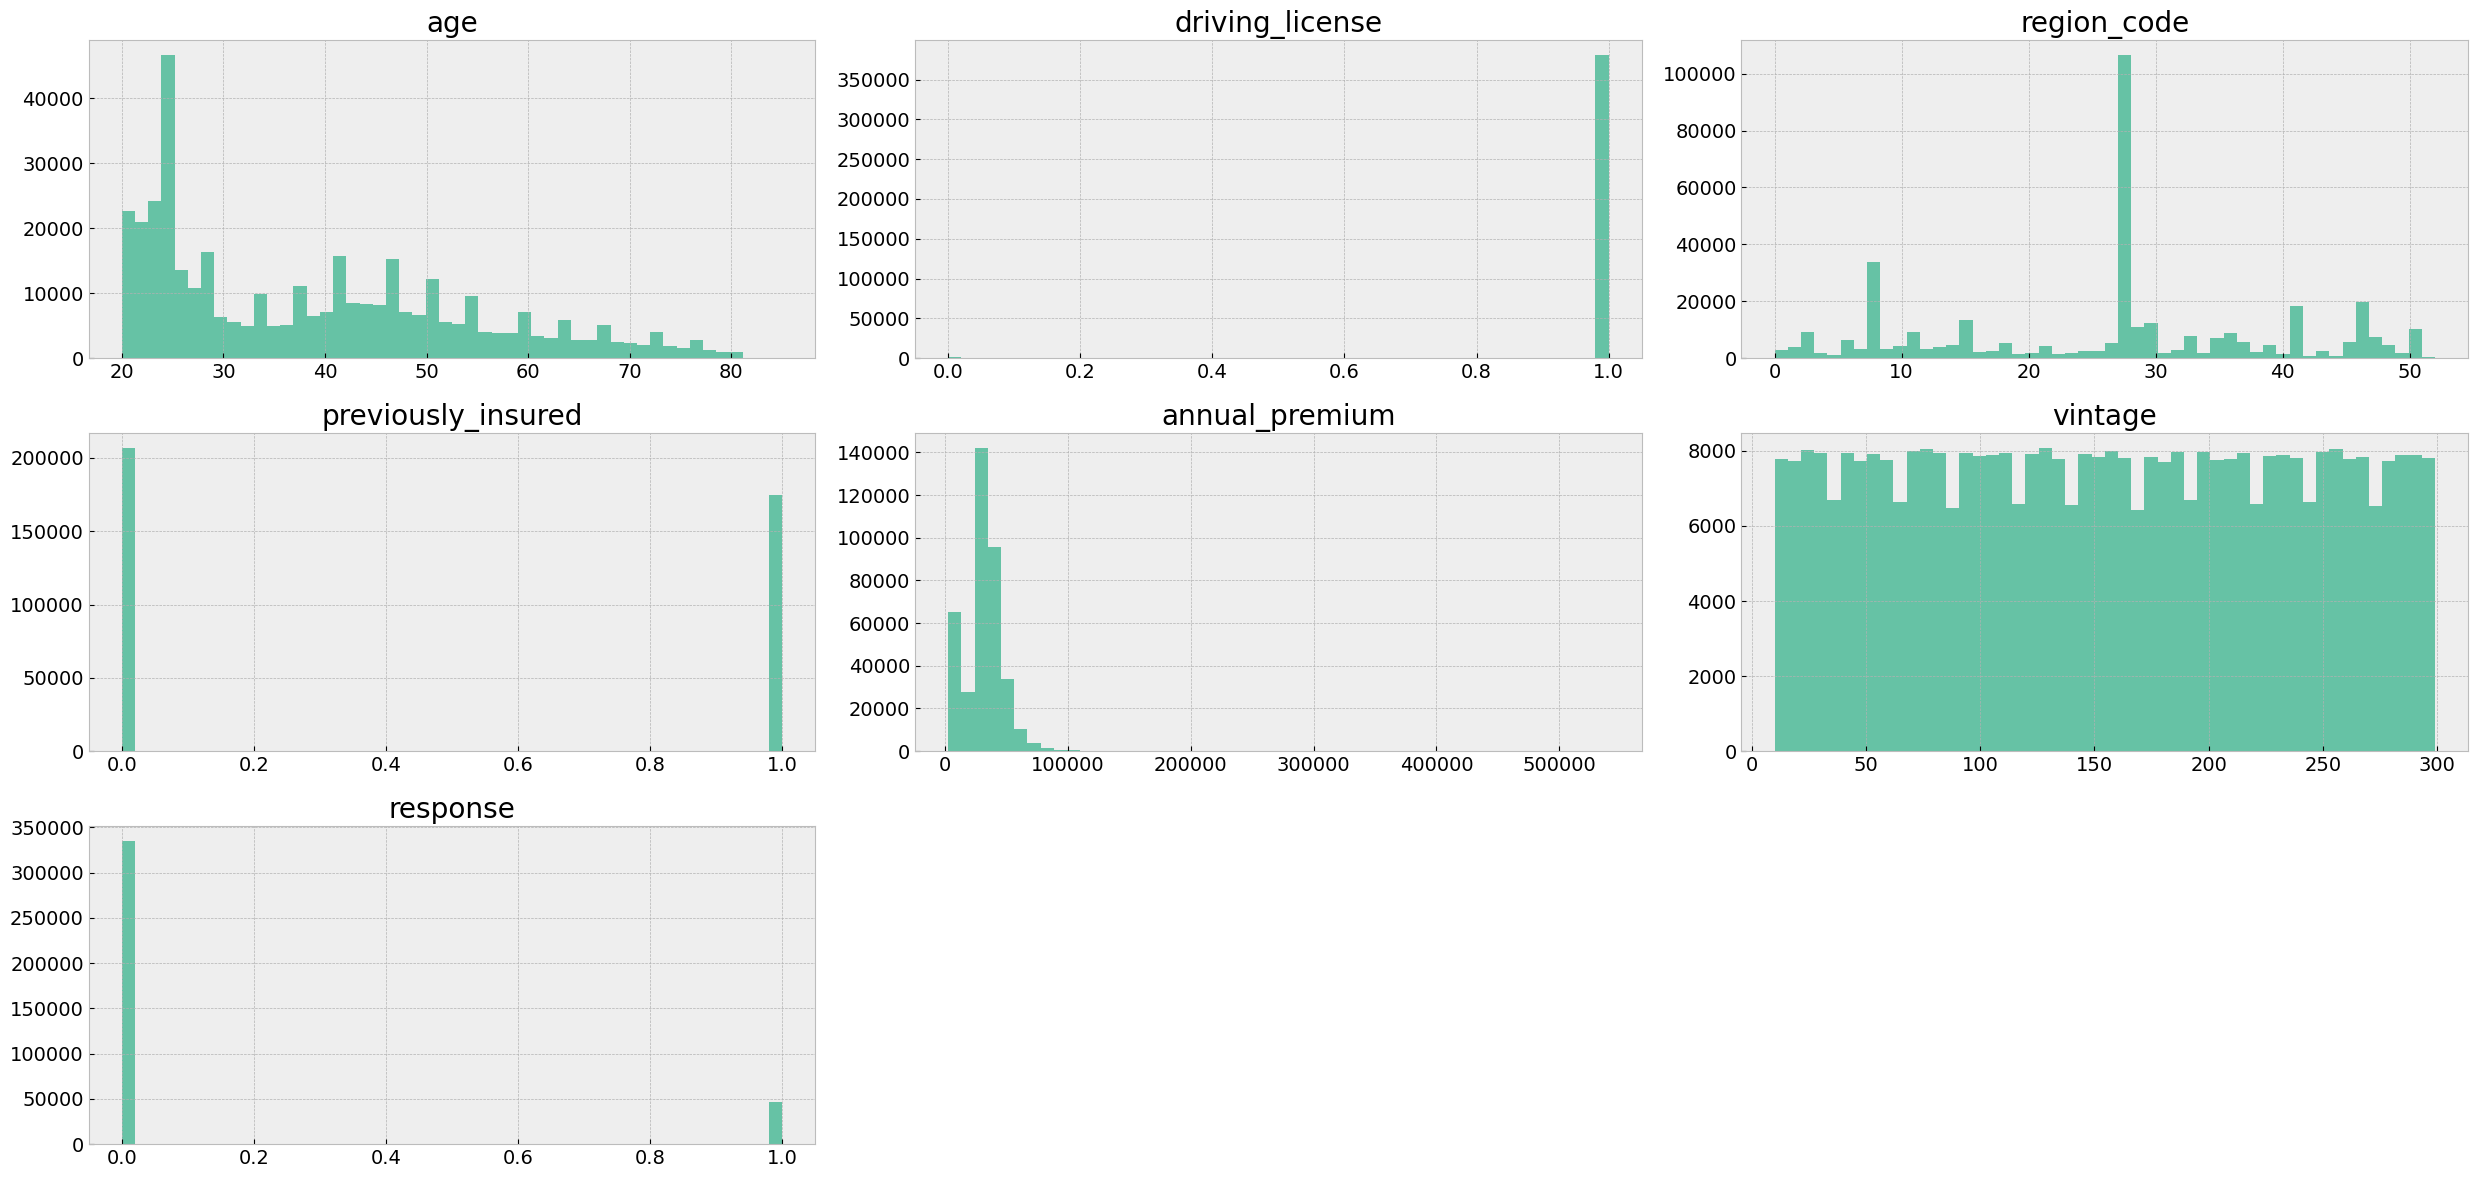

In [23]:
num_attributes.hist(bins=50)
plt.tight_layout()
plt.show()

### 4.1.2 Categorical

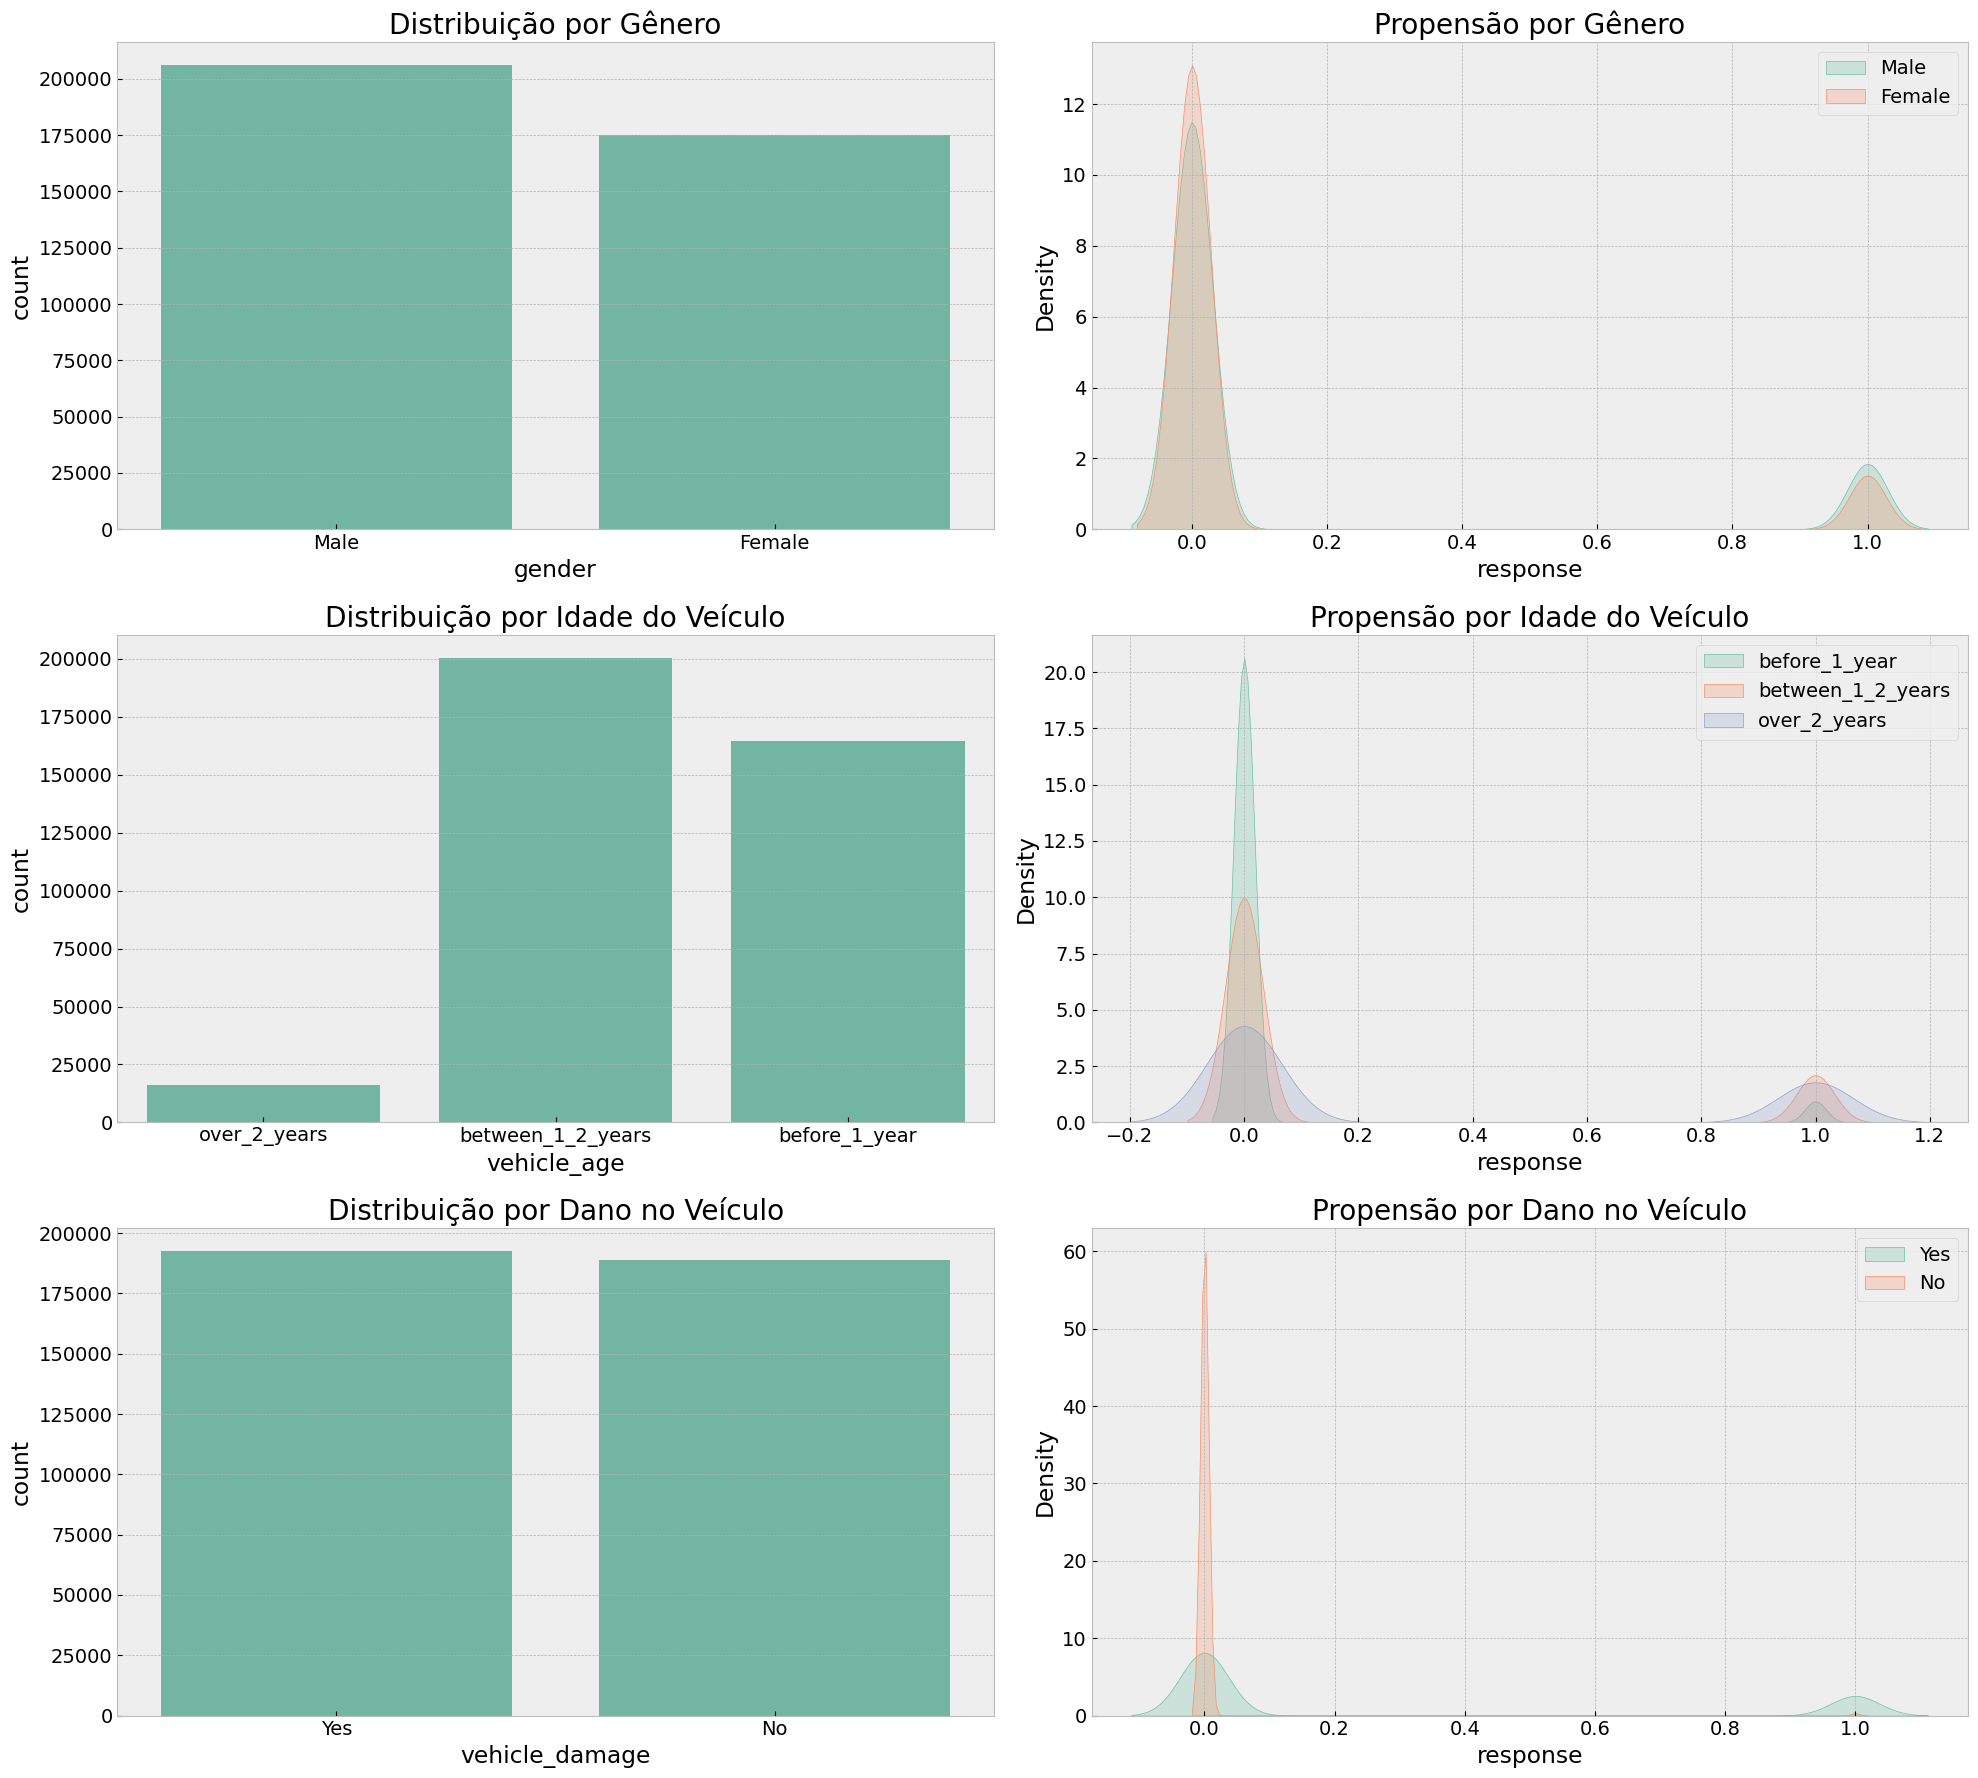

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(20, 18))

# gender - countplot
sns.countplot(x='gender', data=df4, ax=axes[0,0])
axes[0,0].set_title('Distribuição por Gênero')

# gender - KDE
sns.kdeplot(df4[df4['gender'] == 'Male']['response'], label='Male', fill=True, ax=axes[0,1])
sns.kdeplot(df4[df4['gender'] == 'Female']['response'], label='Female', fill=True, ax=axes[0,1])
axes[0,1].set_title('Propensão por Gênero')
axes[0,1].legend()

# vehicle_age - countplot
sns.countplot(x='vehicle_age', data=df4, ax=axes[1,0])
axes[1,0].set_title('Distribuição por Idade do Veículo')

# vehicle_age - KDE
sns.kdeplot(df4[df4['vehicle_age'] == 'before_1_year']['response'], label='before_1_year', fill=True, ax=axes[1,1])
sns.kdeplot(df4[df4['vehicle_age'] == 'between_1_2_years']['response'], label='between_1_2_years', fill=True, ax=axes[1,1])
sns.kdeplot(df4[df4['vehicle_age'] == 'over_2_years']['response'], label='over_2_years', fill=True, ax=axes[1,1])
axes[1,1].set_title('Propensão por Idade do Veículo')
axes[1,1].legend()

# vehicle_damage - countplot
sns.countplot(x='vehicle_damage', data=df4, ax=axes[2,0])
axes[2,0].set_title('Distribuição por Dano no Veículo')

# vehicle_damage - KDE
sns.kdeplot(df4[df4['vehicle_damage'] == 'Yes']['response'], label='Yes', fill=True, ax=axes[2,1])
sns.kdeplot(df4[df4['vehicle_damage'] == 'No']['response'], label='No', fill=True, ax=axes[2,1])
axes[2,1].set_title('Propensão por Dano no Veículo')
axes[2,1].legend()

plt.tight_layout()
plt.show()

## 4.2 Bivariate Analysis

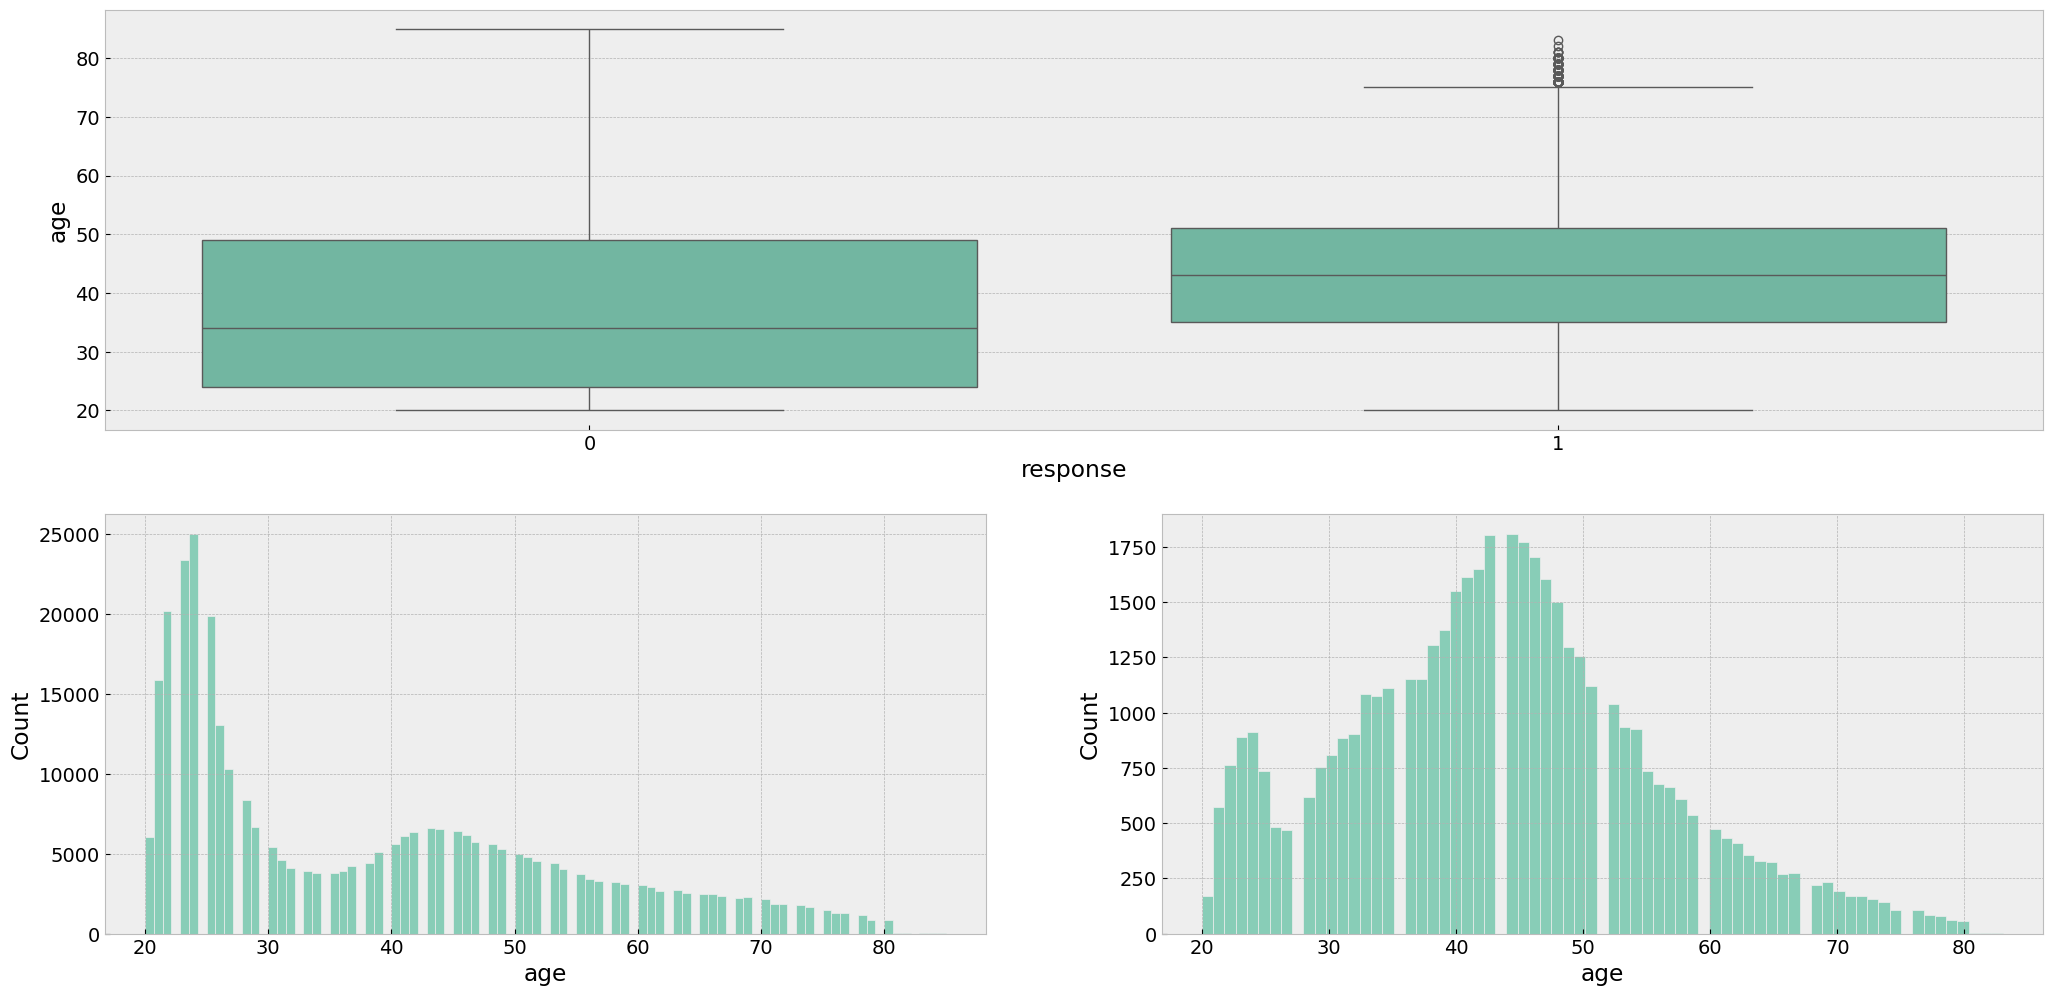

In [25]:
# age
plt.subplot(2,1,1)
sns.boxplot(x='response', y='age', data=df4)

plt.subplot(2,2,3)
sns.histplot(df4.loc[df4['response'] == 0, 'age'])

plt.subplot(2,2,4)
sns.histplot(df4.loc[df4['response'] == 1, 'age']);

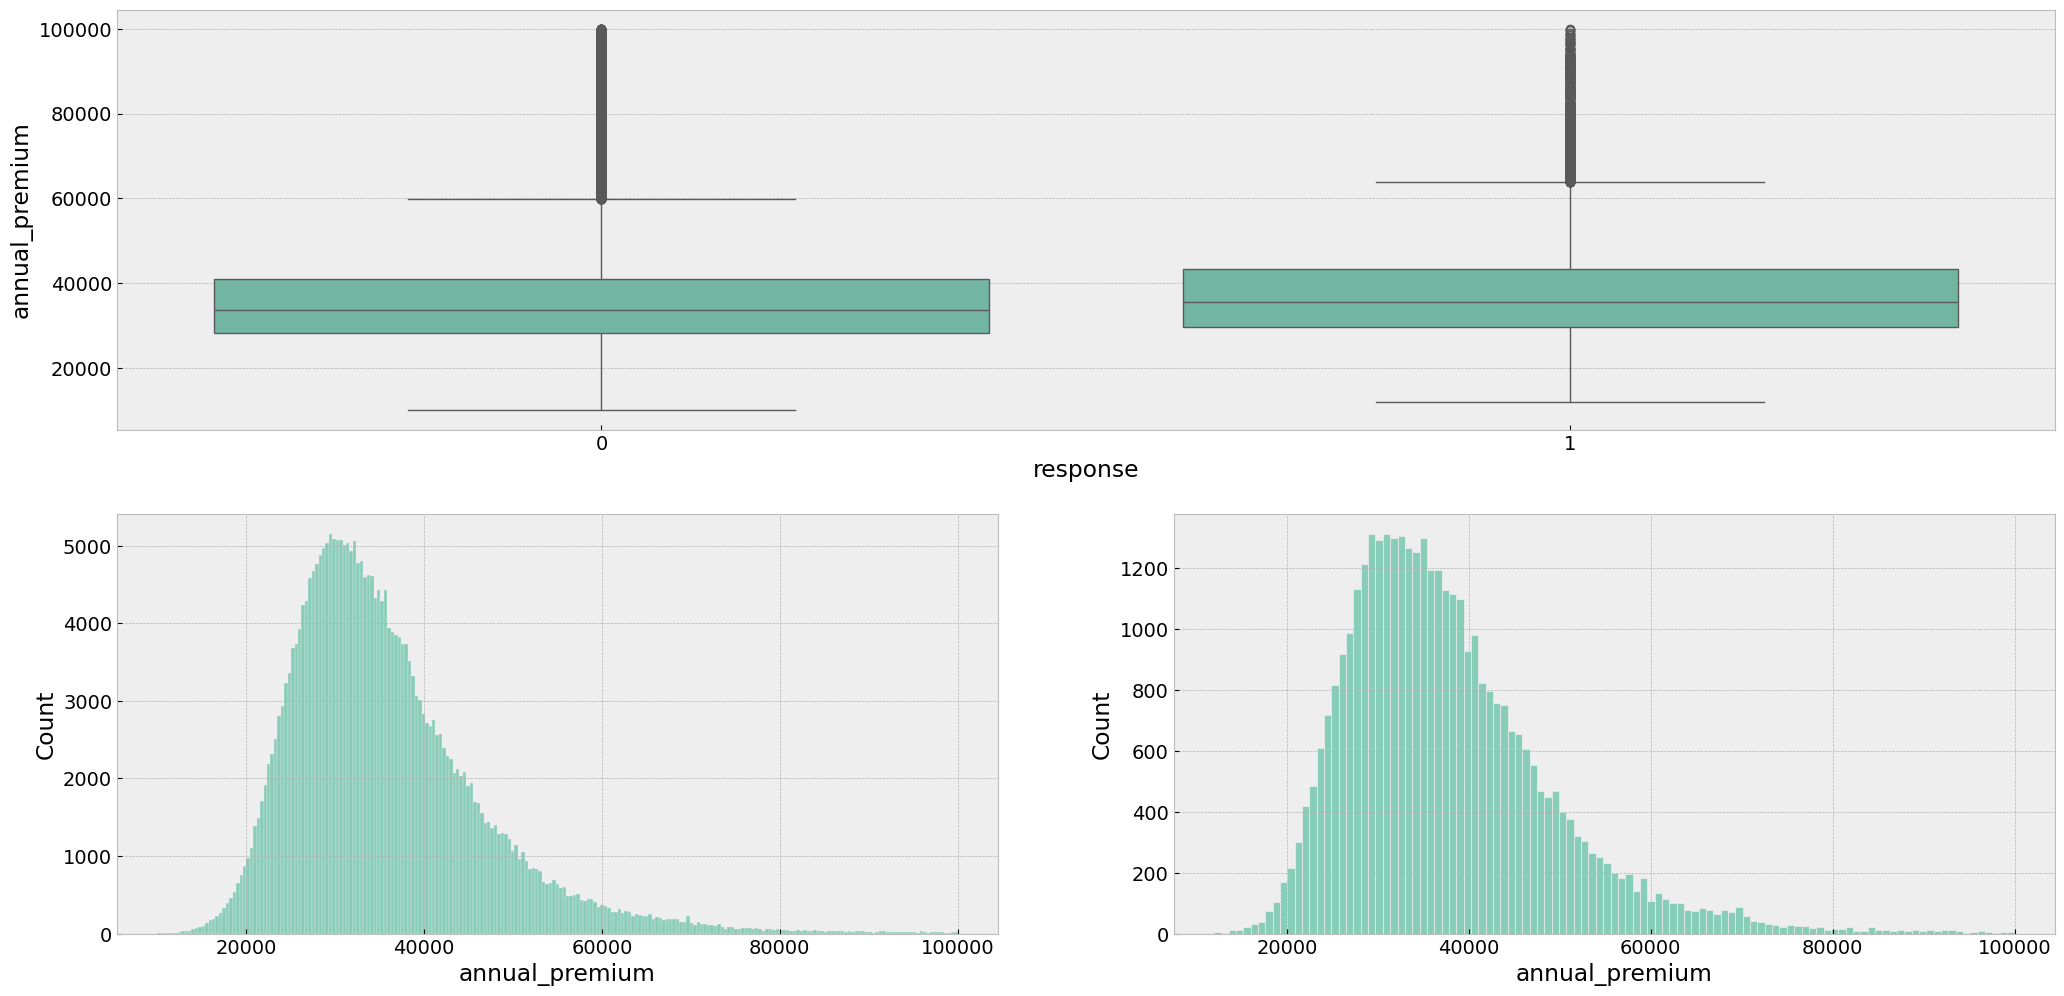

In [26]:
# annual_premium
aux = df4[(df4['annual_premium'] > 10000) & (df4['annual_premium'] < 100000) ]

plt.subplot(2,1,1)
sns.boxplot(x='response', y='annual_premium', data=aux)

plt.subplot(2,2,3)
sns.histplot(aux.loc[aux['response'] == 0, 'annual_premium'])

plt.subplot(2,2,4)
sns.histplot(aux.loc[aux['response'] == 1, 'annual_premium']);

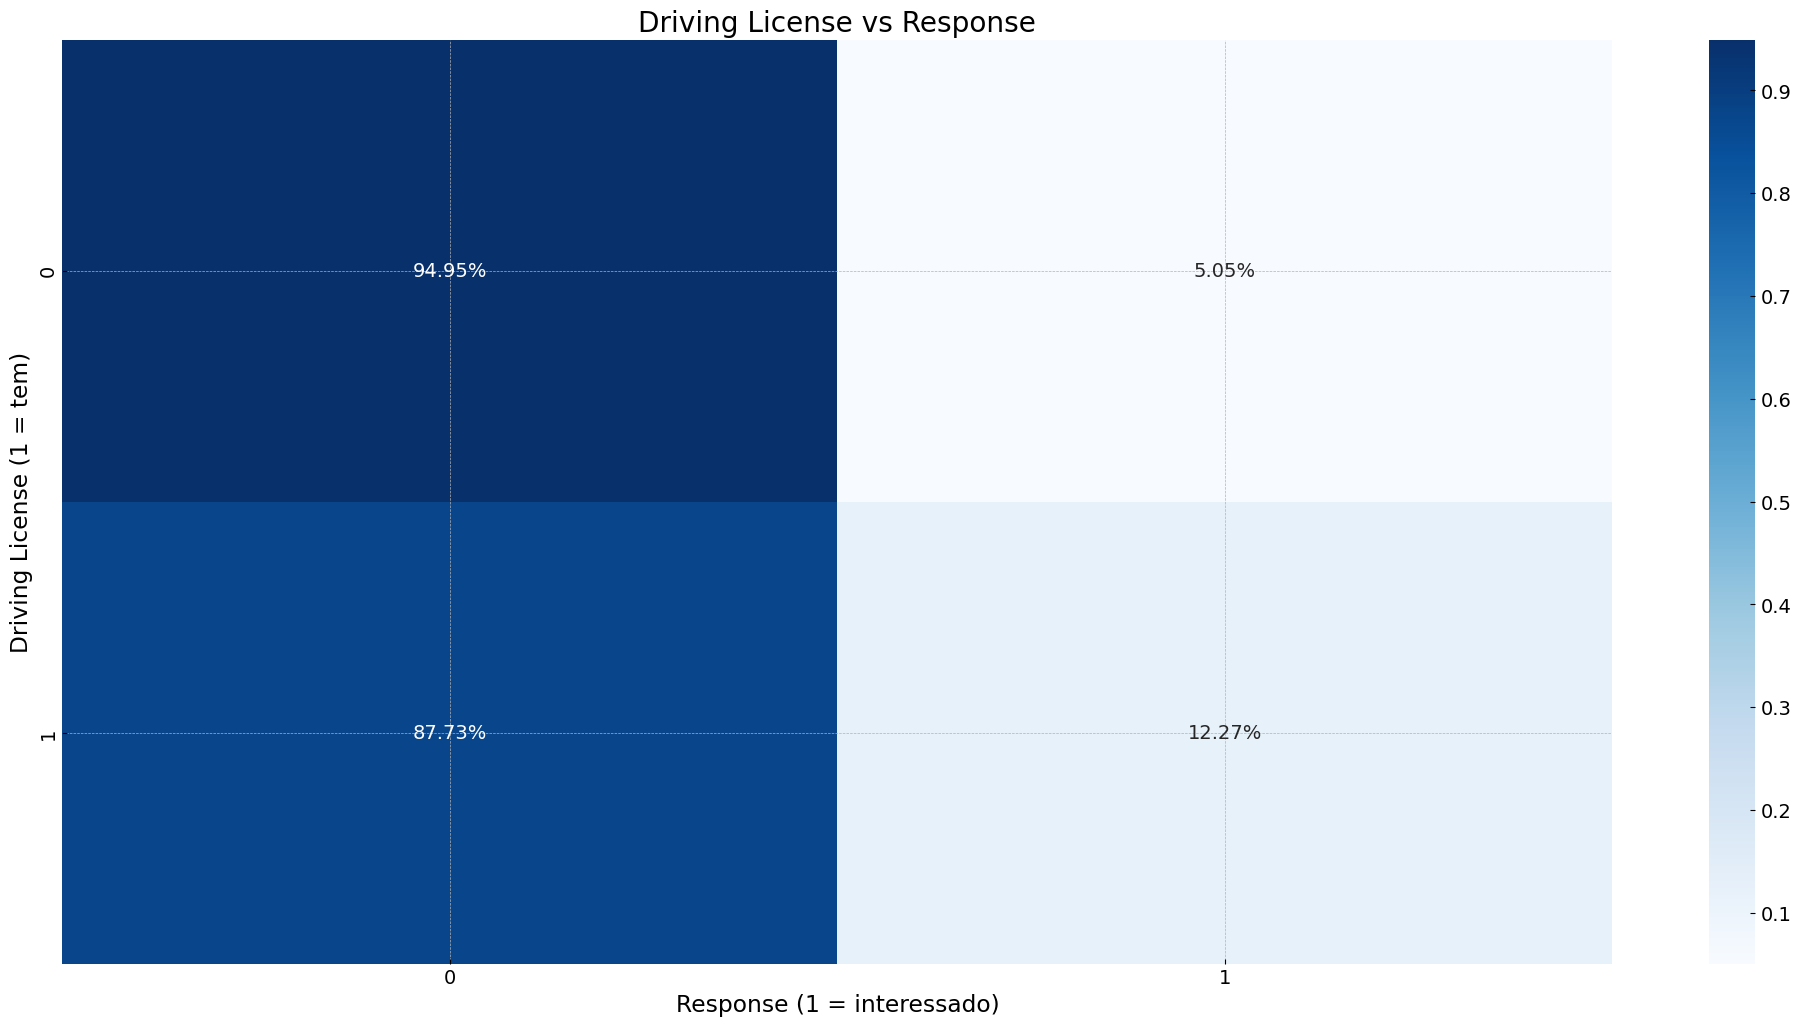

In [27]:
# driving_license

# Tabela cruzada
crosstab_prop = pd.crosstab(
    df4['driving_license'], 
    df4['response'], 
    normalize='index'
)

# Heatmap 
sns.heatmap(
    crosstab_prop,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    cbar=True
)

plt.title('Driving License vs Response')
plt.xlabel('Response (1 = interessado)')
plt.ylabel('Driving License (1 = tem)')
plt.show()

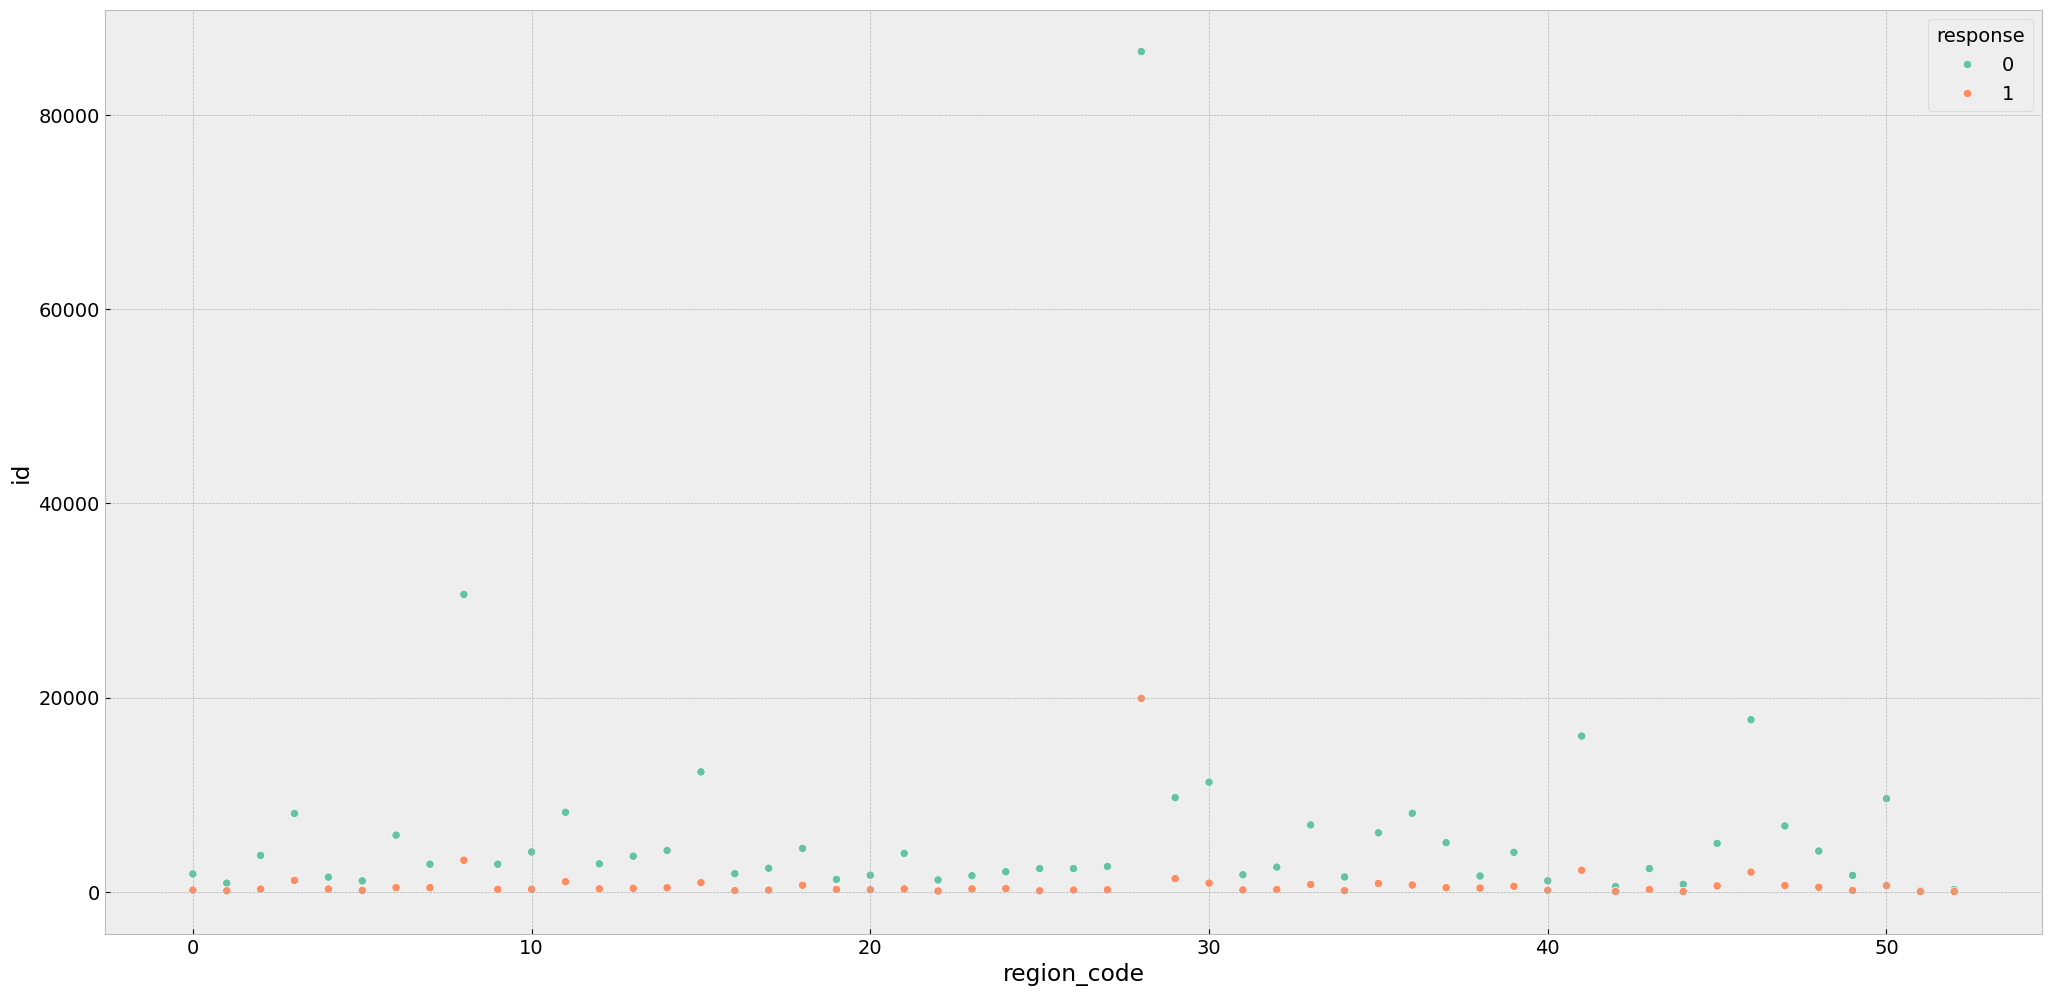

In [28]:
# region_code

ax = df4[['id', 'region_code', 'response']].groupby(['region_code', 'response']).count().reset_index()

sns.scatterplot(x='region_code', y='id', hue='response', data=ax);

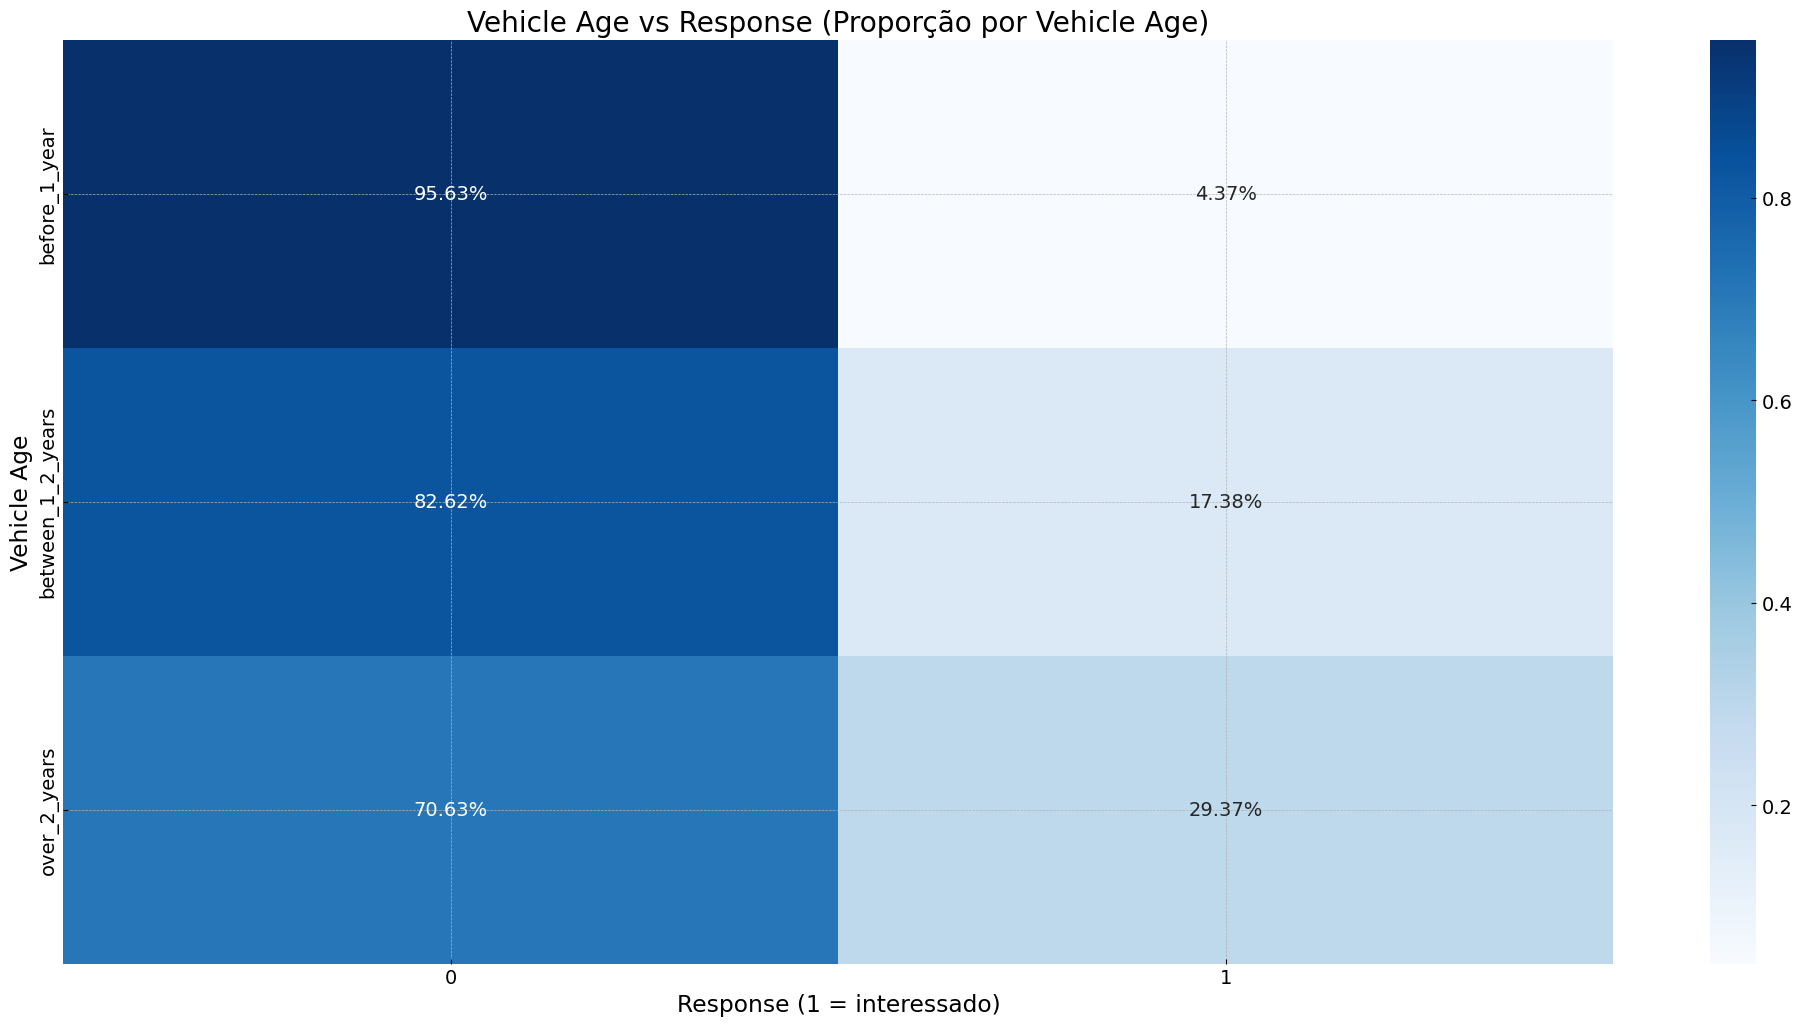

In [29]:
# vehicle_age


# Crosstab
crosstab_prop = pd.crosstab(
    df4['vehicle_age'],
    df4['response'],
    normalize='index'
)


sns.heatmap(
    crosstab_prop,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    cbar=True
)

plt.title('Vehicle Age vs Response (Proporção por Vehicle Age)')
plt.xlabel('Response (1 = interessado)')
plt.ylabel('Vehicle Age')
plt.show()


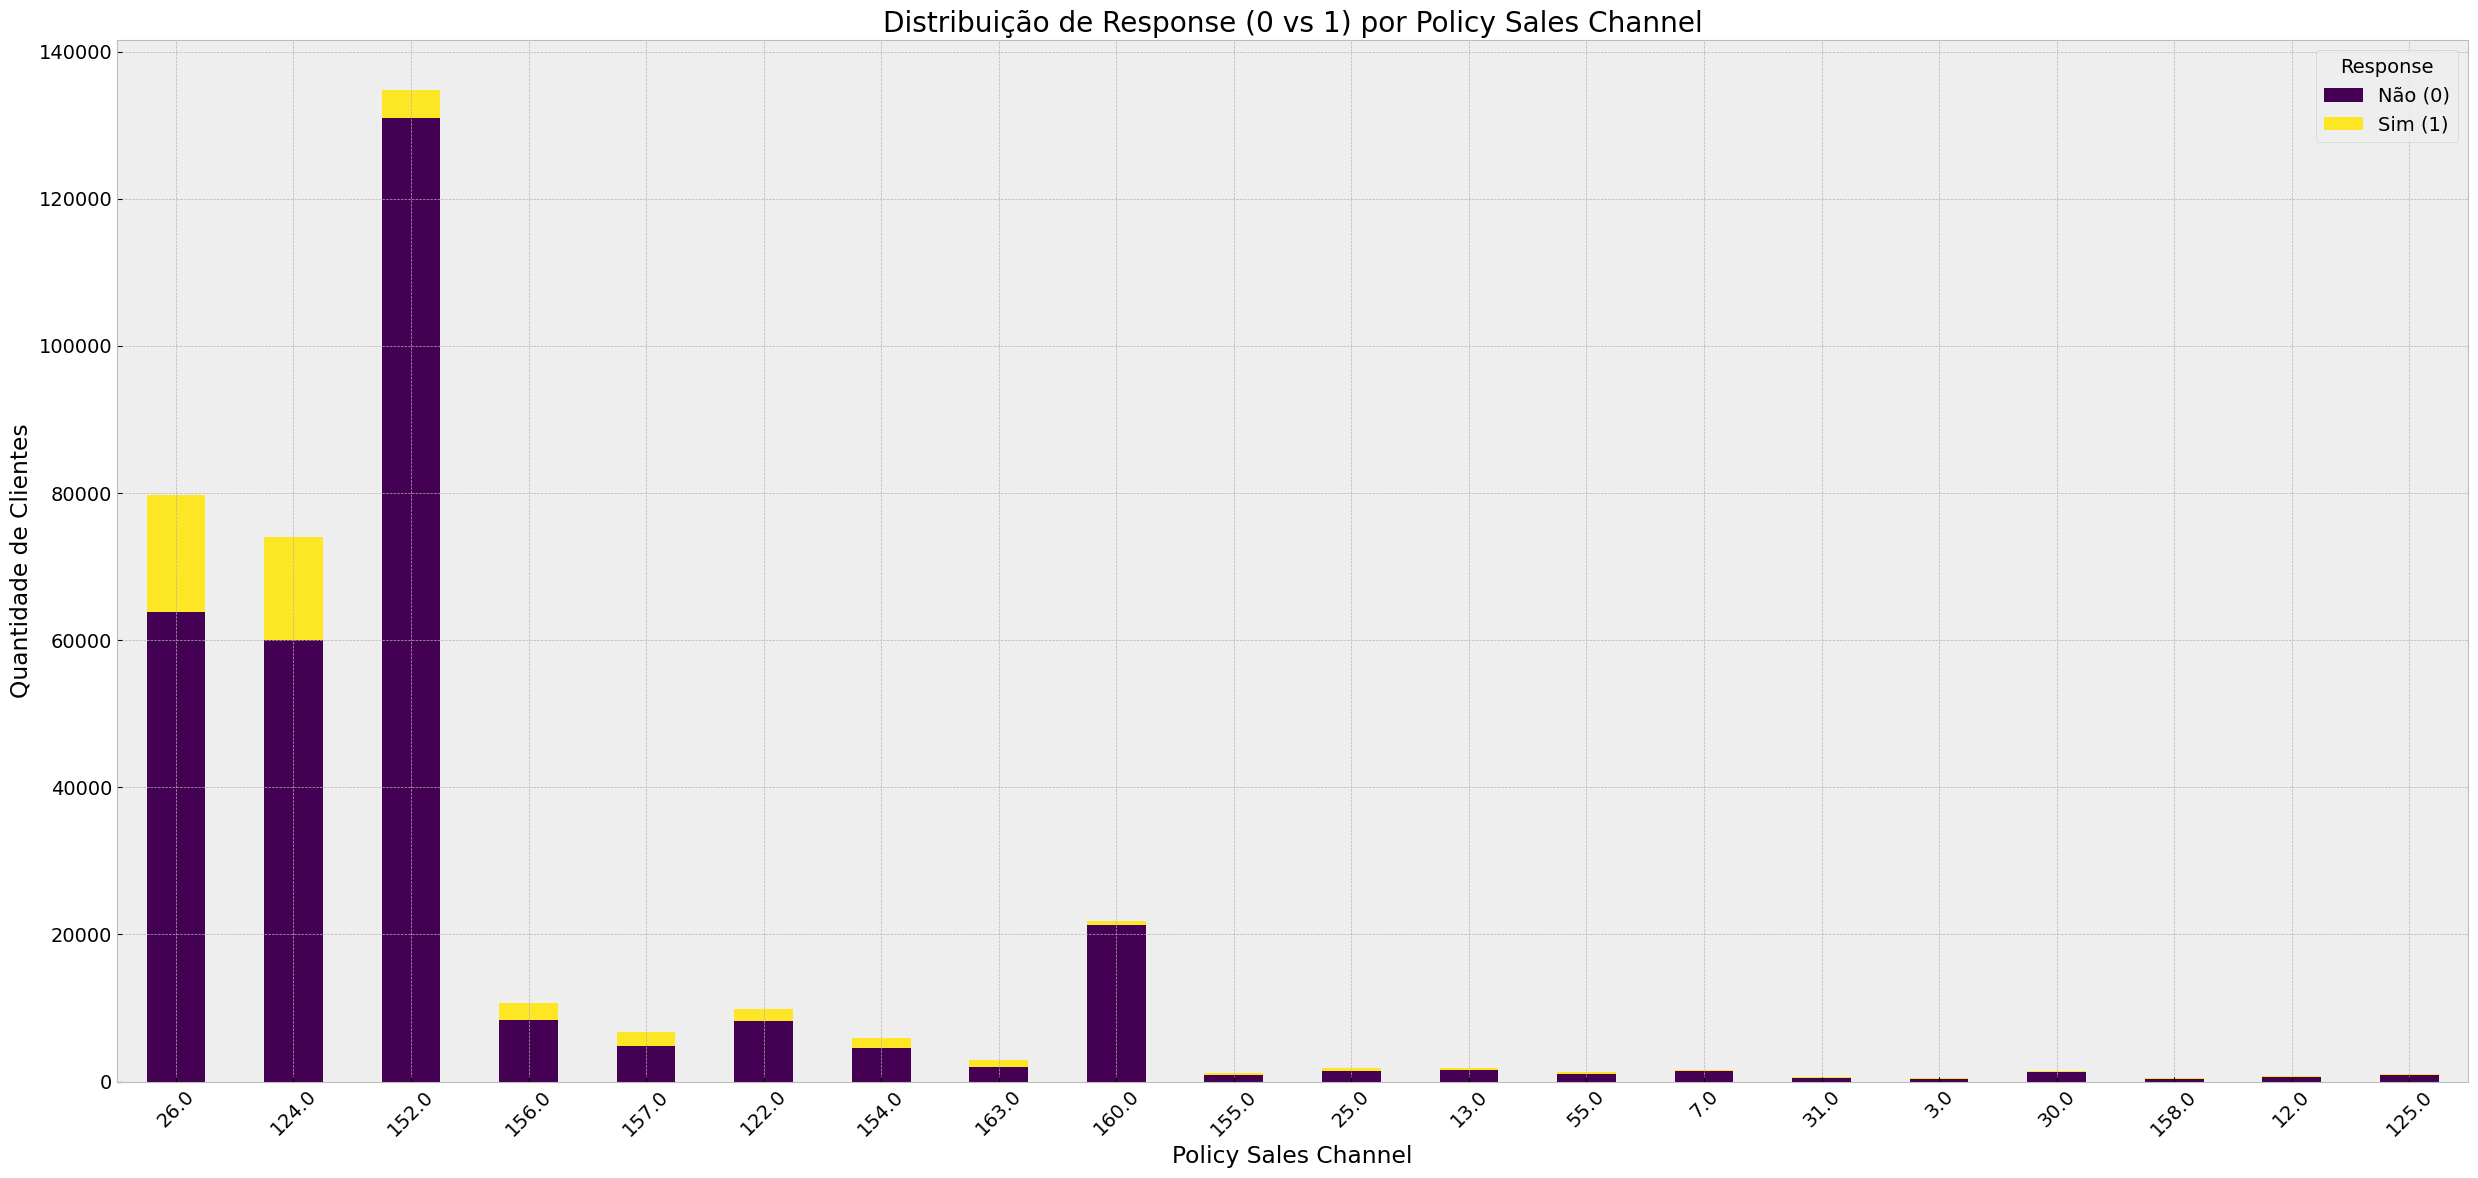

In [30]:
# policy_sales_channel

channel_response = pd.crosstab(
    df4['policy_sales_channel'],
    df4['response']
)

# canais mais relevantes
channel_response = channel_response.sort_values(1, ascending=False).head(20)

channel_response.plot(
    kind='bar',      
    stacked=True,
    ax=plt.gca(),
    colormap='viridis'
)

plt.xlabel('Policy Sales Channel')
plt.ylabel('Quantidade de Clientes')
plt.title('Distribuição de Response (0 vs 1) por Policy Sales Channel')

plt.legend(
    title='Response',
    labels=['Não (0)', 'Sim (1)']
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



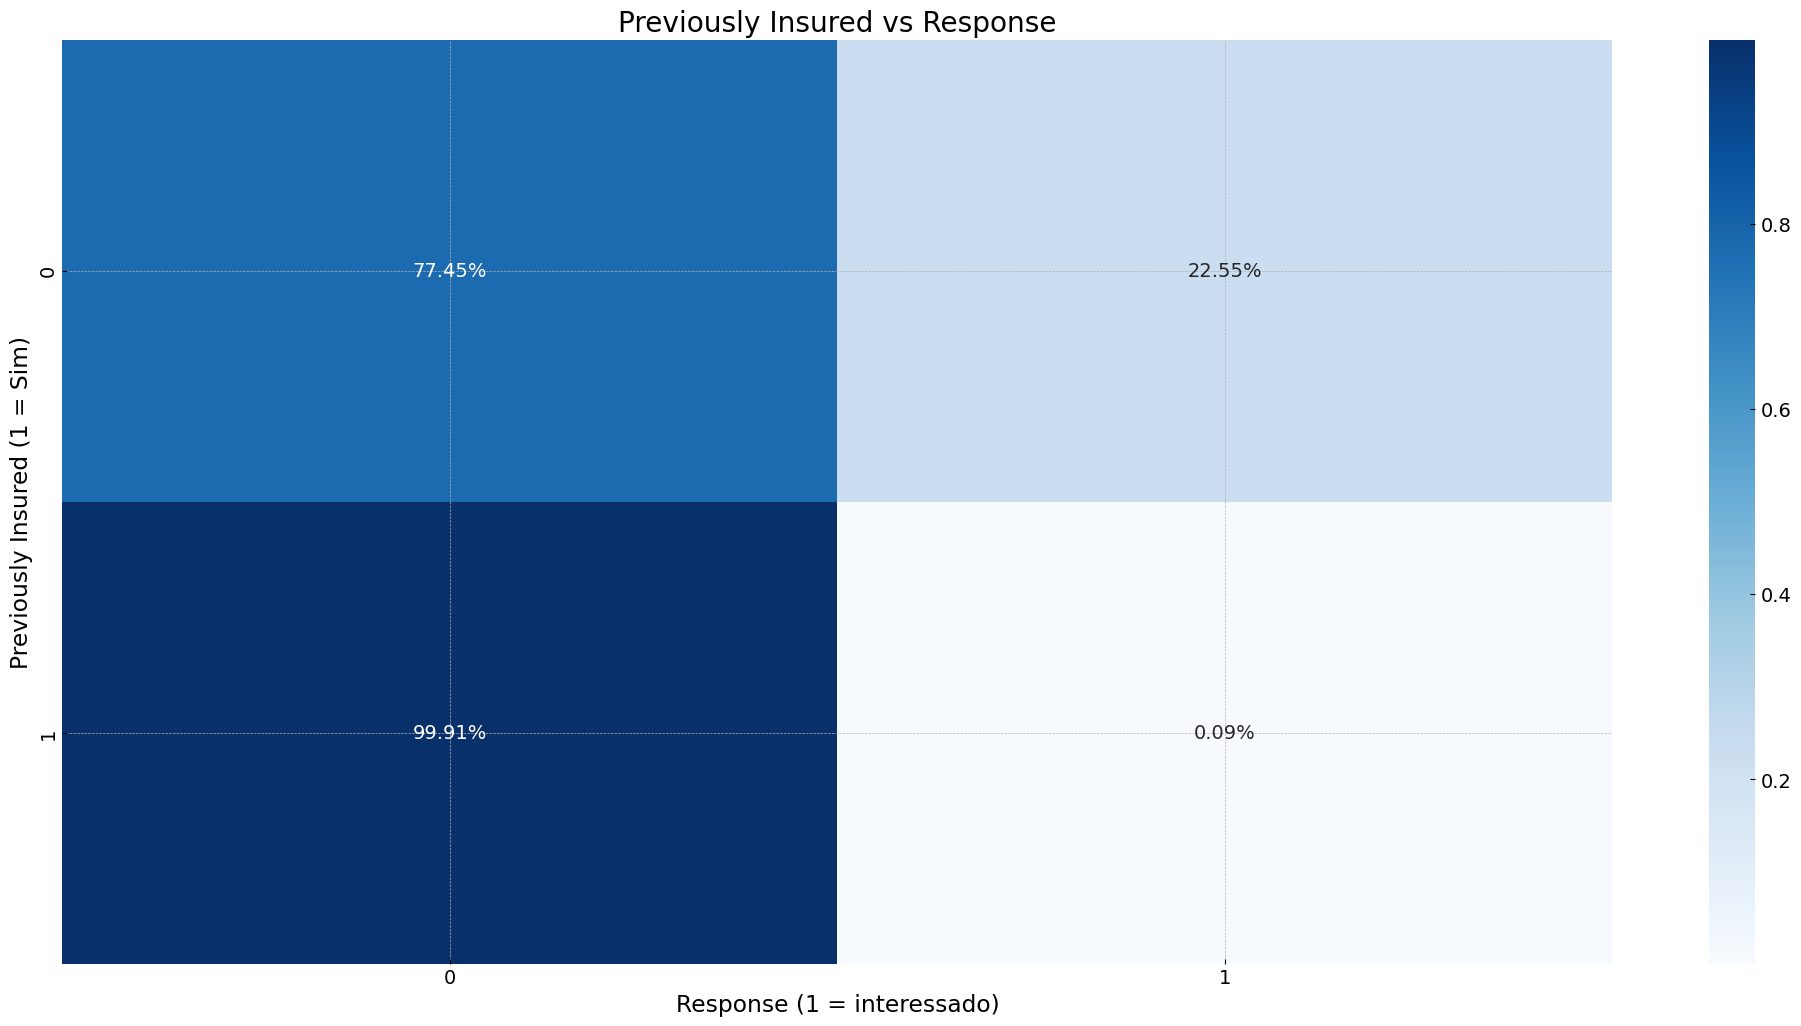

In [31]:
# previously_insured

# Tabela cruzada
crosstab_prop = pd.crosstab(
    df4['previously_insured'], 
    df4['response'], 
    normalize='index'
)

# Heatmap 
sns.heatmap(
    crosstab_prop,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    cbar=True
)

plt.title('Previously Insured vs Response')
plt.xlabel('Response (1 = interessado)')
plt.ylabel('Previously Insured (1 = Sim)')
plt.show()

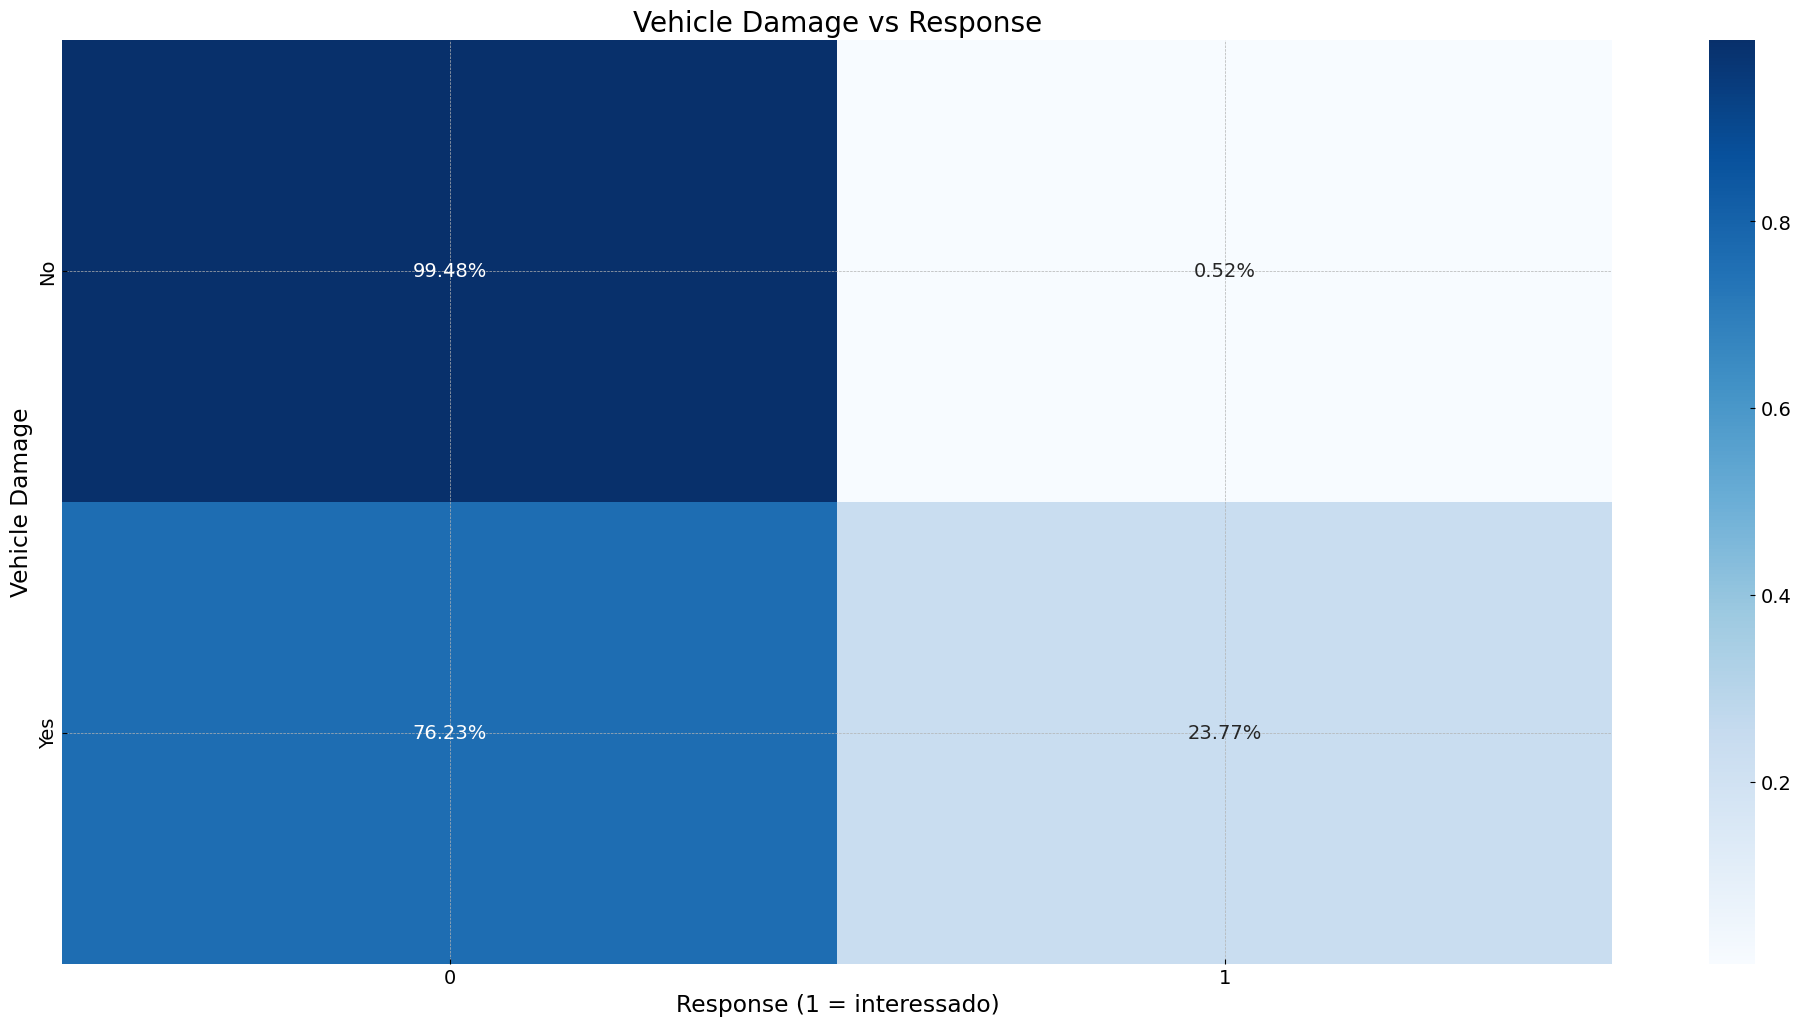

In [32]:
# vehicle_damage

# Tabela cruzada
crosstab_prop = pd.crosstab(
    df4['vehicle_damage'], 
    df4['response'], 
    normalize='index'
)

# Heatmap 
sns.heatmap(
    crosstab_prop,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    cbar=True
)

plt.title('Vehicle Damage vs Response')
plt.xlabel('Response (1 = interessado)')
plt.ylabel('Vehicle Damage')
plt.show()

/tmp/ipykernel_4262/3033814677.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count = df4.groupby(['age_group', 'response']).size().unstack(fill_value=0)


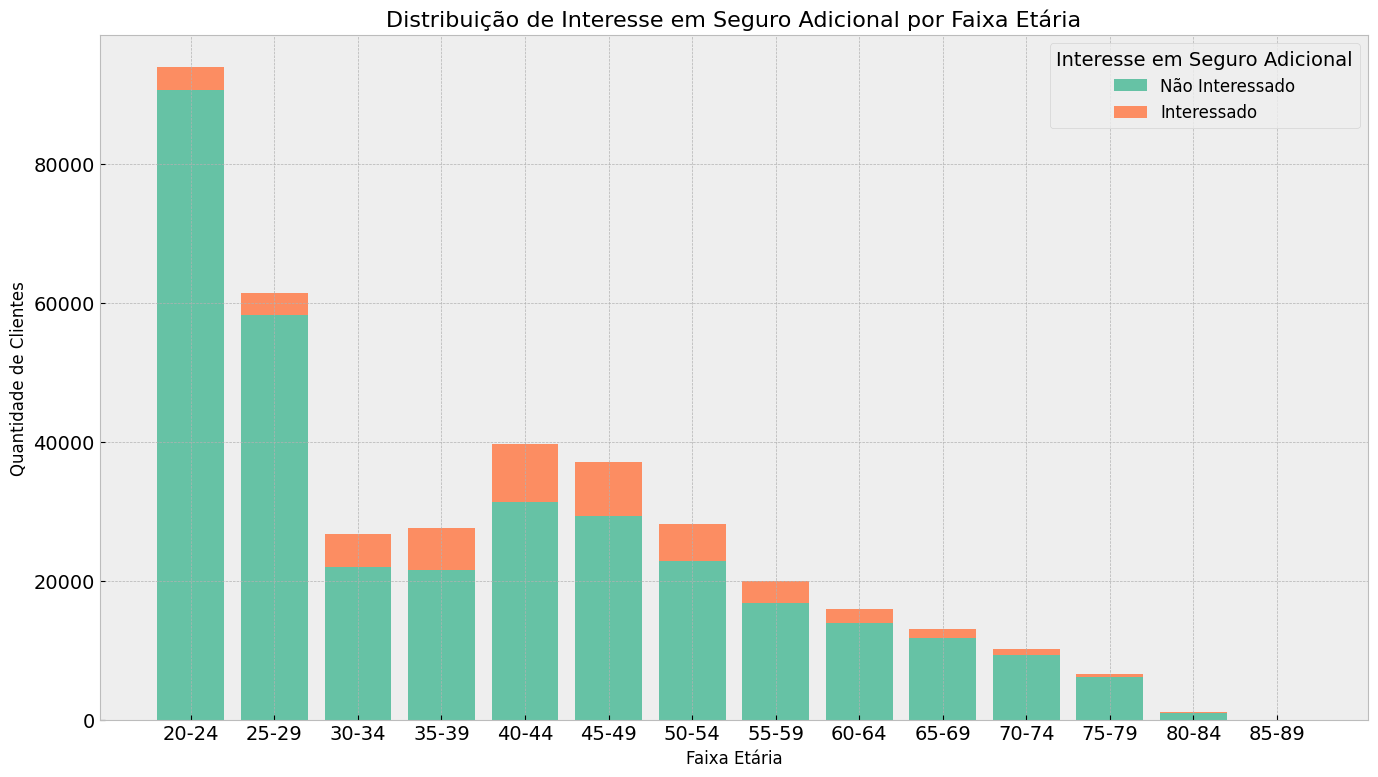

In [33]:
# Calcula a contagem de response = 0 e 1 por age_group
count = df4.groupby(['age_group', 'response']).size().unstack(fill_value=0)
count.columns = ['Não Interessado', 'Interessado']

count = count.sort_index()

fig, ax = plt.subplots(figsize=(14, 8))

bottom = None
for col in count.columns:
    ax.bar(count.index.astype(str), count[col], label=col, bottom=bottom)
    if bottom is None:
        bottom = count[col].values
    else:
        bottom += count[col].values

ax.set_title('Distribuição de Interesse em Seguro Adicional por Faixa Etária', fontsize=16)
ax.set_xlabel('Faixa Etária', fontsize=12)
ax.set_ylabel('Quantidade de Clientes', fontsize=12)
ax.legend(title='Interesse em Seguro Adicional', fontsize=12)

plt.tight_layout()
plt.show()

# 5 - DATA PREPARATION

In [34]:
X = df4.drop(columns=['response', 'age_group'])
y = df4['response'].copy()

x_train, x_val, y_train, y_val = train_test_split (X, y, test_size=0.20, random_state=42, stratify=y)

df5 = pd.concat([x_train, y_train], axis=1)

### 5.1.1 Stardalization

In [35]:
ss = StandardScaler()

ss.fit(df5[['annual_premium']])

,copy,True
,with_mean,True
,with_std,True


### 5.1.2 Rescaling

In [36]:
mms_age = MinMaxScaler()
mms_vintage = MinMaxScaler()

mms_age.fit(df5[['age']])
mms_vintage.fit(df5[['vintage']])

,feature_range,"(0, ...)"
,copy,True
,clip,False


### 5.1.3 Escoding

In [37]:
te_region = TargetEncoder()
te_policy = TargetEncoder()
gender_dict = {'Male': 1, 'Female': 0}
damage_dict = {'Yes': 1, 'No': 0}
vehicle_dict = {'before_1_year': 1,
                'between_1_2_years': 2,
                'over_2_years': 3}


te_region.fit(df5[['region_code']], df5['response'])
te_policy.fit(df5[['policy_sales_channel']], df5['response'])


,categories,'auto'
,target_type,'auto'
,smooth,'auto'
,cv,5
,shuffle,True
,random_state,None


In [38]:
preprocessing = {
    'scalers': {
        'annual_premium': ss,
        'age': mms_age,
        'vintage': mms_vintage
    },
    'target_encoders': {
        'region_code': te_region,
        'policy_sales_channel': te_policy
    },
    'mappings': {
        'gender': gender_dict,
        'vehicle_damage': damage_dict,
        'vehicle_age': vehicle_dict
    }
}

with open('../preprocessing/preprocessing.pkl', 'wb') as f:
    pickle.dump(preprocessing, f)

In [39]:
import pickle

with open('../preprocessing/preprocessing.pkl', 'rb') as f:
    preprocessing = pickle.load(f)

# =========================
# SCALERS
# =========================
ss = preprocessing['scalers']['annual_premium']
mms_age = preprocessing['scalers']['age']
mms_vintage = preprocessing['scalers']['vintage']

# =========================
# TARGET ENCODERS
# =========================
te_region = preprocessing['target_encoders']['region_code']
te_policy = preprocessing['target_encoders']['policy_sales_channel']

# =========================
# FIXED MAPPINGS
# =========================
gender_dict = preprocessing['mappings']['gender']
damage_dict = preprocessing['mappings']['vehicle_damage']
vehicle_dict = preprocessing['mappings']['vehicle_age']

## 5.4 Train Preparation

In [40]:
x_train.loc[:, 'annual_premium'] = ss.transform(
    x_train[['annual_premium']]
)

x_train.loc[:, 'age'] = mms_age.transform(
    x_train[['age']]
)

x_train.loc[:, 'vintage'] = mms_vintage.transform(
    x_train[['vintage']]
)

x_train.loc[:, 'region_code'] = te_region.transform(
    x_train[['region_code']]
)

x_train.loc[:, 'policy_sales_channel'] = te_policy.transform(
    x_train[['policy_sales_channel']]
)

x_train['gender'] = (
    x_train['gender']
    .map(gender_dict)
    .fillna(0)
    .astype('int64')
)

x_train['vehicle_damage'] = (
    x_train['vehicle_damage']
    .map(damage_dict)
    .fillna(0)
    .astype('int64')
)

x_train['vehicle_age'] = (
    x_train['vehicle_age']
    .map(vehicle_dict)
    .fillna(0)
    .astype('int64')
)



/tmp/ipykernel_4262/2890785884.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.03076923 0.09230769 0.18461538 ... 0.06153846 0.30769231 0.06153846]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_train.loc[:, 'age'] = mms_age.transform(
/tmp/ipykernel_4262/2890785884.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.66782007 0.12110727 0.08650519 ... 0.1799308  0.87197232 0.85121107]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_train.loc[:, 'vintage'] = mms_vintage.transform(


In [41]:
x_train.dtypes

id                        int64
gender                    int64
age                     float64
driving_license           int64
region_code             float64
previously_insured        int64
vehicle_age               int64
vehicle_damage            int64
annual_premium          float64
policy_sales_channel    float64
vintage                 float64
dtype: object

## 5.5 Validation Preparation

In [42]:
x_val.loc[:, 'annual_premium'] = ss.transform(
    x_val[['annual_premium']]
)

x_val.loc[:, 'age'] = mms_age.transform(
    x_val[['age']]
)

x_val.loc[:, 'vintage'] = mms_vintage.transform(
    x_val[['vintage']]
)

x_val.loc[:, 'region_code'] = te_region.transform(
    x_val[['region_code']]
)

x_val.loc[:, 'policy_sales_channel'] = te_policy.transform(
    x_val[['policy_sales_channel']]
)

x_val['gender'] = (
    x_val['gender']
    .map(gender_dict)
    .fillna(0)
    .astype('int64')
)

x_val['vehicle_damage'] = (
    x_val['vehicle_damage']
    .map(damage_dict)
    .fillna(0)
    .astype('int64')
)

x_val['vehicle_age'] = (
    x_val['vehicle_age']
    .map(vehicle_dict)
    .fillna(0)
    .astype('int64')
)

#x_val.loc[:, 'gender'] = x_val['gender'].map(gender_dict) 
#x_val.loc[:, 'vehicle_damage'] = x_val['vehicle_damage'].map(damage_dict)
#x_val.loc[:, 'vehicle_age'] = x_val['vehicle_age'].map(vehicle_dict)


/tmp/ipykernel_4262/1060478063.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.52307692 0.09230769 0.07692308 ... 0.61538462 0.04615385 0.58461538]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_val.loc[:, 'age'] = mms_age.transform(
/tmp/ipykernel_4262/1060478063.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.14878893 0.93425606 0.84775087 ... 0.95155709 0.30449827 0.77854671]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_val.loc[:, 'vintage'] = mms_vintage.transform(


In [43]:
x_val.dtypes

id                        int64
gender                    int64
age                     float64
driving_license           int64
region_code             float64
previously_insured        int64
vehicle_age               int64
vehicle_damage            int64
annual_premium          float64
policy_sales_channel    float64
vintage                 float64
dtype: object

# 6 - FEATURE SELECTION

## 6.1 Boruta

In [44]:
x_train_fs = x_train.drop(columns=['id'])
y_train_fs = y_train.copy()

In [45]:
# rf = RandomForestClassifier(
#     n_estimators=1000,
#     max_depth=None,
#     min_samples_leaf=1,
#     max_features='sqrt',
#     n_jobs=-1,
#     random_state=42,
#     class_weight='balanced_subsample'
# )
#
# boruta = BorutaPy(
#     estimator=rf,
#     n_estimators='auto',
#     verbose=2,
#     random_state=42
# )
#
# boruta.fit(
#     x_train_fs.values,
#     y_train_fs.values
# )


In [46]:
selected_features = ['previously_insured', 'vehicle_damage', 'policy_sales_channel']
selected_features

['previously_insured', 'vehicle_damage', 'policy_sales_channel']

## 6.2 Feature Importance

In [47]:
# rf_importance = RandomForestClassifier(
#     n_estimators=1000,
#     max_depth=None,
#     min_samples_leaf=1,
#     max_features='sqrt',
#     n_jobs=-1,
#     random_state=42,
#     class_weight='balanced_subsample'
# )
#
#
# rf_importance.fit(x_train_fs, y_train_fs)

In [48]:
# importances = np.mean(
#     [tree.feature_importances_ for tree in rf_importance.estimators_], 
#     axis=0
# )
# std = np.std(
#     [tree.feature_importances_ for tree in rf_importance.estimators_], 
#     axis=0
# )
#
# # Índices ordenados (do maior pro menor)
# indices = np.argsort(importances)[::-1]
#
# # Cria DataFrame com ranking
# feature_ranking = pd.DataFrame({
#     'feature': x_train_fs.columns if hasattr(x_train_fs, 'columns') else [f'feature_{i}' for i in range(x_train_fs.shape[1])],
#     'importance': importances,
#     'std': std
# })
#
# # Ordena do maior pro menor
# feature_ranking = feature_ranking.sort_values('importance', ascending=False).reset_index(drop=True)
#
# print("Feature ranking:")
# print(feature_ranking)
#
# # Plot das importâncias
# plt.title("Feature Importances (Random Forest)")
# plt.bar(
#     range(x_train_fs.shape[1]), 
#     importances[indices],
#     color="r",
#     yerr=std[indices],
#     align="center"
# )
# plt.xticks(
#     range(x_train_fs.shape[1]), 
#     [feature_ranking['feature'].iloc[i] for i in range(len(indices))],
#     rotation=90
# )
# plt.xlim([-1, x_train_fs.shape[1]])
# plt.tight_layout()
# plt.show()


In [49]:
feature_importance = [
    'vehicle_damage',
    'vintage',
    'previously_insured',
    'policy_sales_channel',
    'annual_premium',
    'region_code',
    'age'
]

# 7 - MACHINE LEARNING

In [50]:
# TREINO
x_train = x_train[feature_importance].copy()

# VALIDAÇÃO
x_val = x_val[feature_importance].copy()


In [51]:
x_train.head()

,vehicle_damage,vintage,previously_insured,policy_sales_channel,annual_premium,region_code,age
274710,1,0.667820,0,0.028816,-0.297943,0.117425,0.030769
216539,0,0.121107,1,0.199687,0.452554,0.095218,0.092308
78983,1,0.086505,0,0.173806,0.088559,0.187041,0.184615
218368,1,0.709343,0,0.028816,0.412993,0.077473,0.184615
307215,1,0.733564,0,0.212094,1.050781,0.187041,0.061538


## 7.1 KNN

In [52]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(x_train, y_train)

# poder de generalizacao
y_val_knn = knn.predict_proba(x_val)[:, 1]

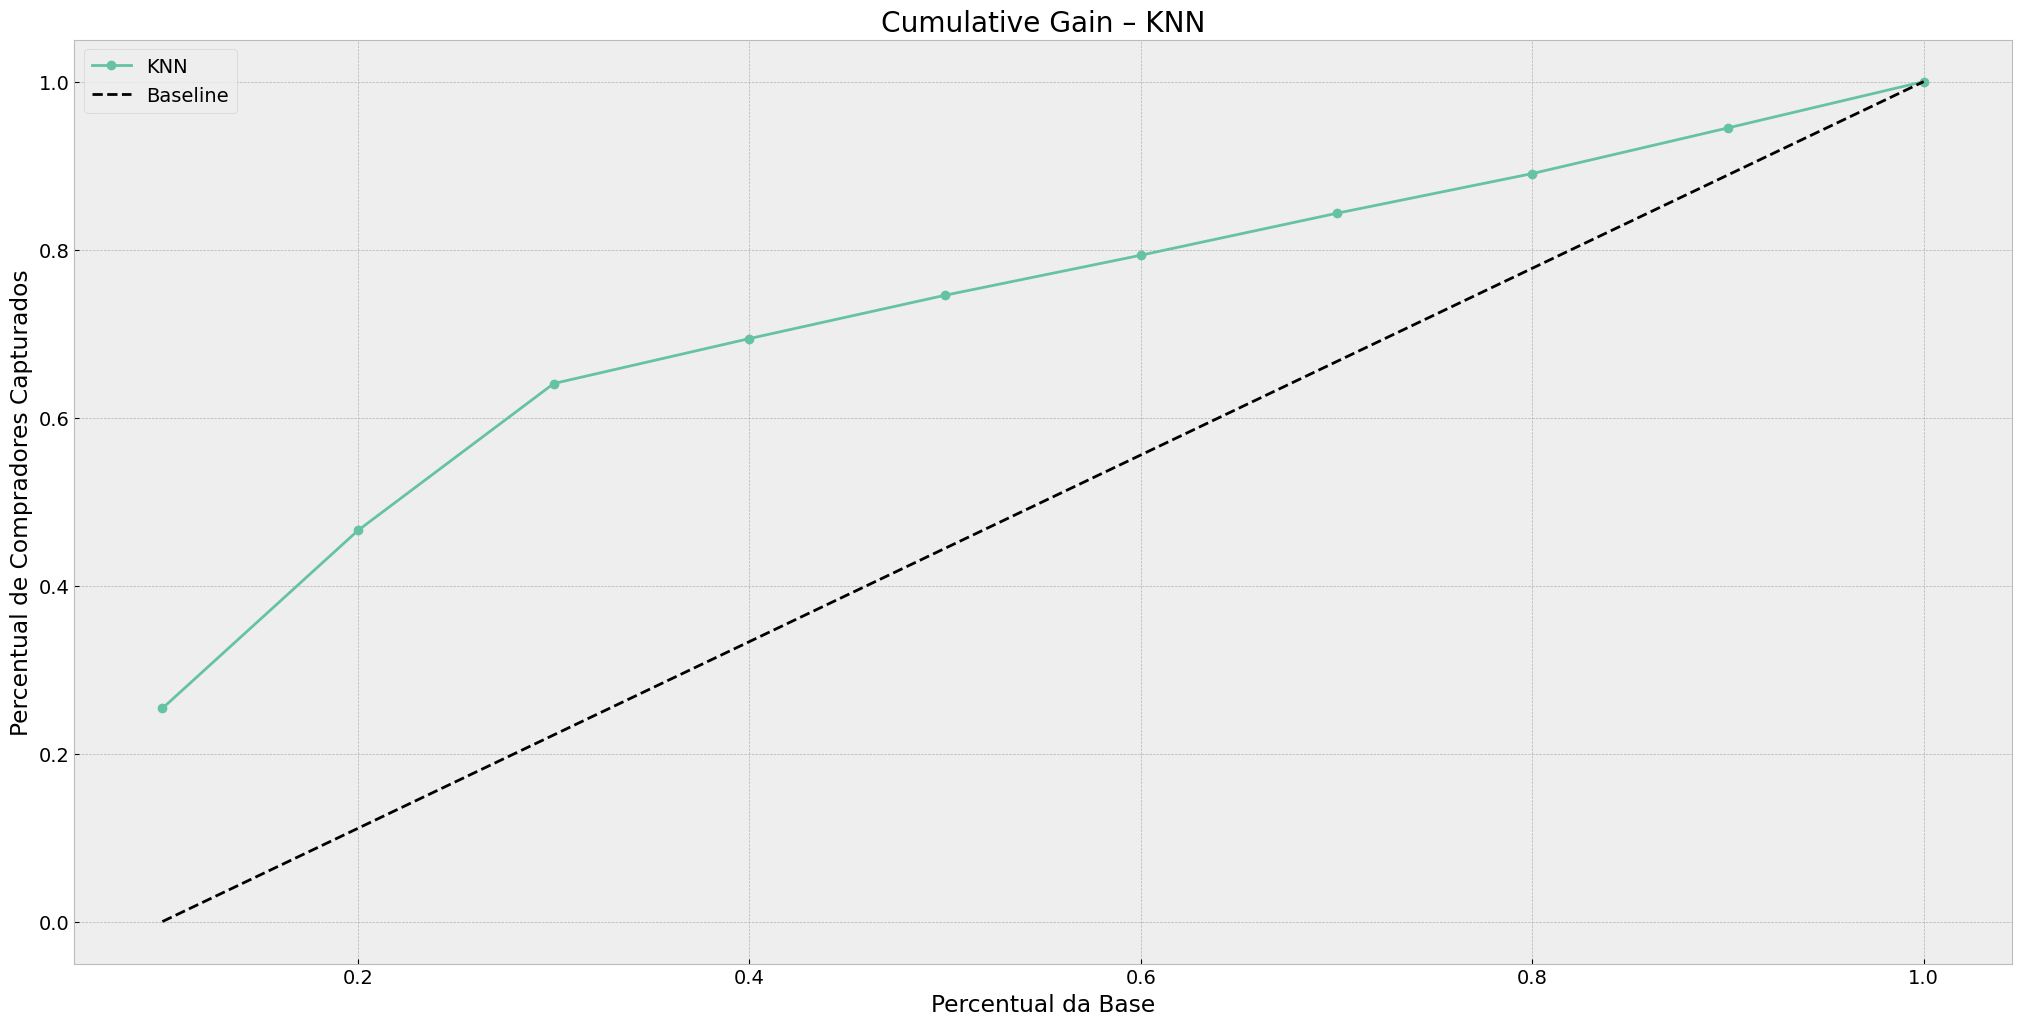

In [53]:
df_rank_knn = x_val.copy()
df_rank_knn['score'] = y_val_knn
df_rank_knn['response'] = y_val.values

cg_knn = cumulative_gain(df_rank_knn)
x_knn = get_x_axis(cg_knn)

plt.plot(x_knn, cg_knn.values, marker='o', label='KNN')
plt.plot(x_knn, np.linspace(0, 1, len(cg_knn)), linestyle='--', color='black', label='Baseline')

plt.title('Cumulative Gain – KNN')
plt.xlabel('Percentual da Base')
plt.ylabel('Percentual de Compradores Capturados')
plt.grid(True)
plt.legend()
plt.show()


## 7.2 Random Forest

In [54]:
rf_model = RandomForestClassifier(
    n_estimators=500,          
    max_depth=None,            
    min_samples_leaf=50,       
    min_samples_split=100,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    class_weight='balanced',
    oob_score=True
)


rf_model.fit(x_train, y_train)

# poder de generalizacao
y_val_rf = rf_model.predict_proba(x_val)[:, 1]


KeyboardInterrupt: 

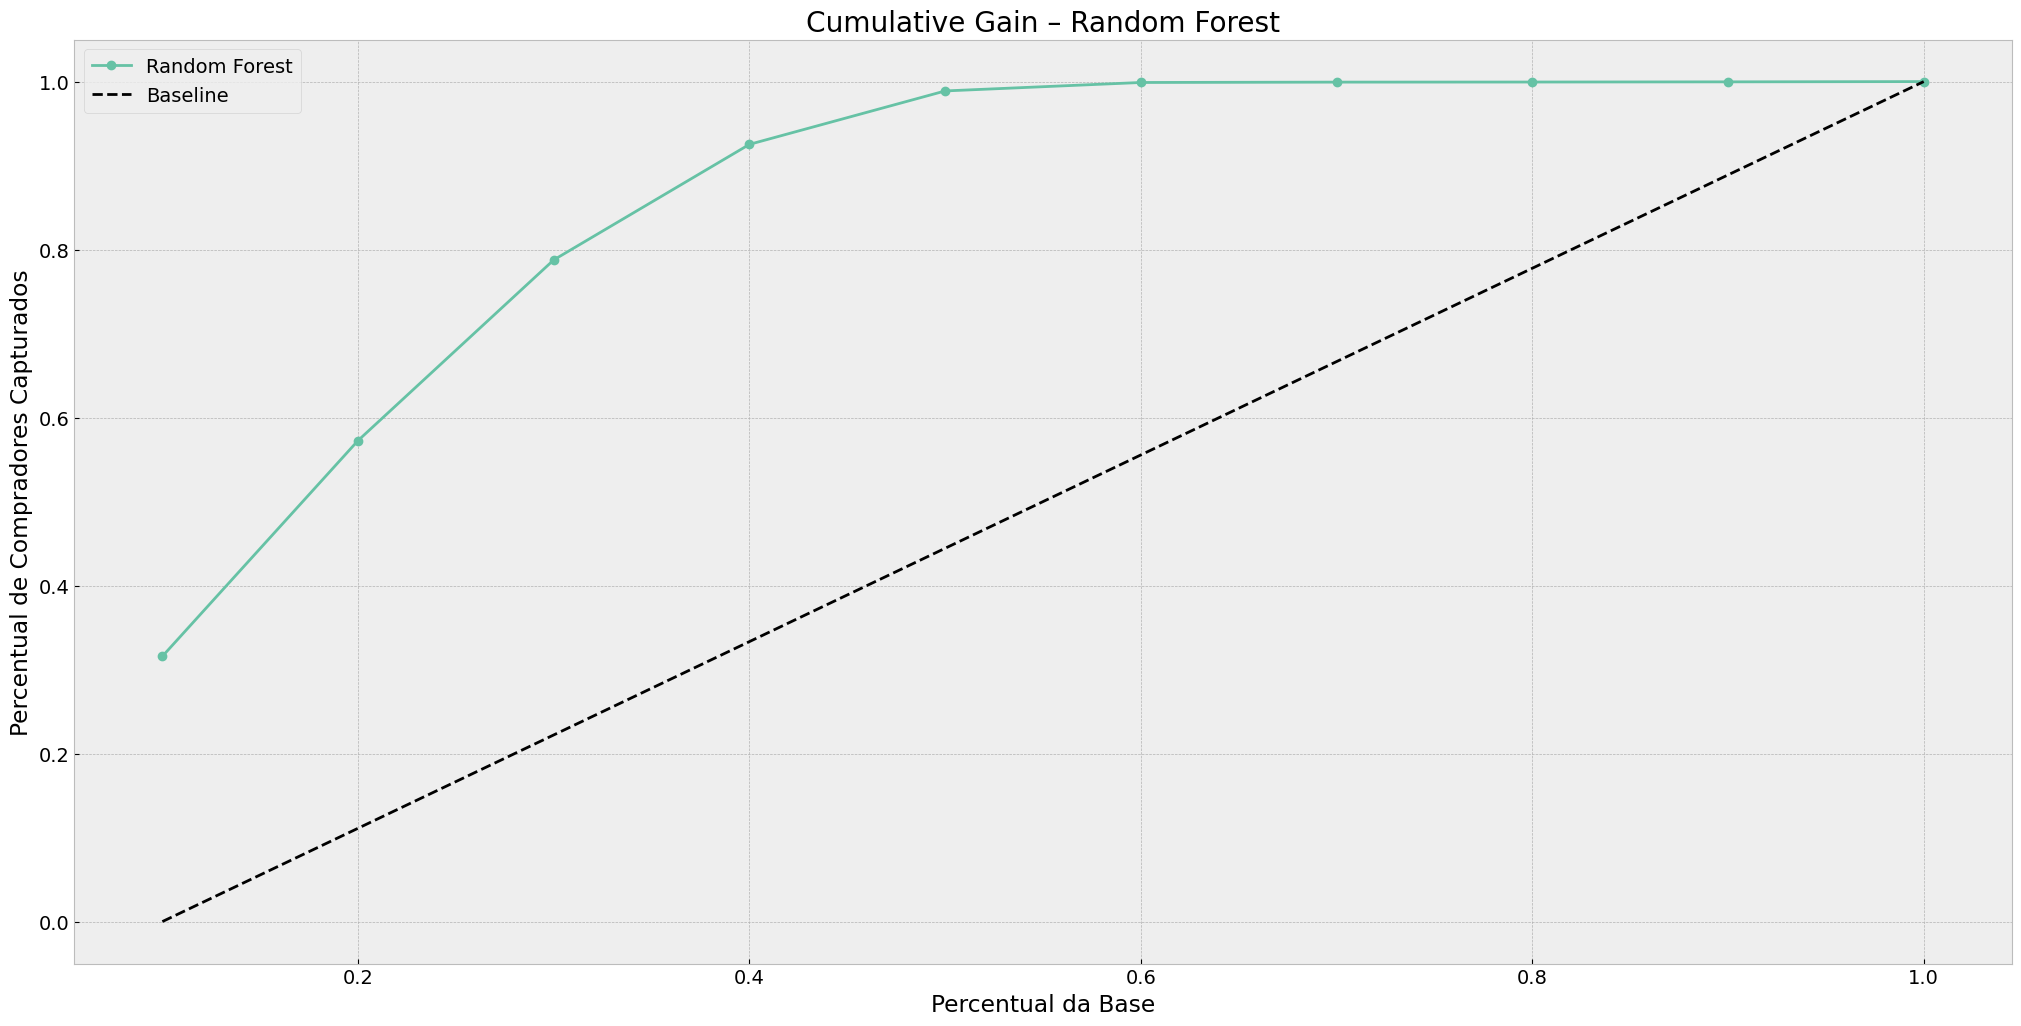

In [ ]:
df_rank_rf = x_val.copy()
df_rank_rf['score'] = y_val_rf
df_rank_rf['response'] = y_val.values

cg_rf = cumulative_gain(df_rank_rf)
x_rf = get_x_axis(cg_rf)

plt.plot(x_rf, cg_rf.values, marker='o', label='Random Forest')
plt.plot(x_rf, np.linspace(0, 1, len(cg_rf)), linestyle='--', color='black', label='Baseline')

plt.title('Cumulative Gain – Random Forest')
plt.xlabel('Percentual da Base')
plt.ylabel('Percentual de Compradores Capturados')
plt.grid(True)
plt.legend()
plt.show()

## 7.3 XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,       
    max_depth=6,
    min_child_weight=50, 
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_alpha=0.0,            
    reg_lambda=1.0,           
    objective='binary:logistic',
    eval_metric='auc',
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(x_train, y_train)

# poder de generalizacao
y_val_xgb = xgb_model.predict_proba(x_val)[:, 1]

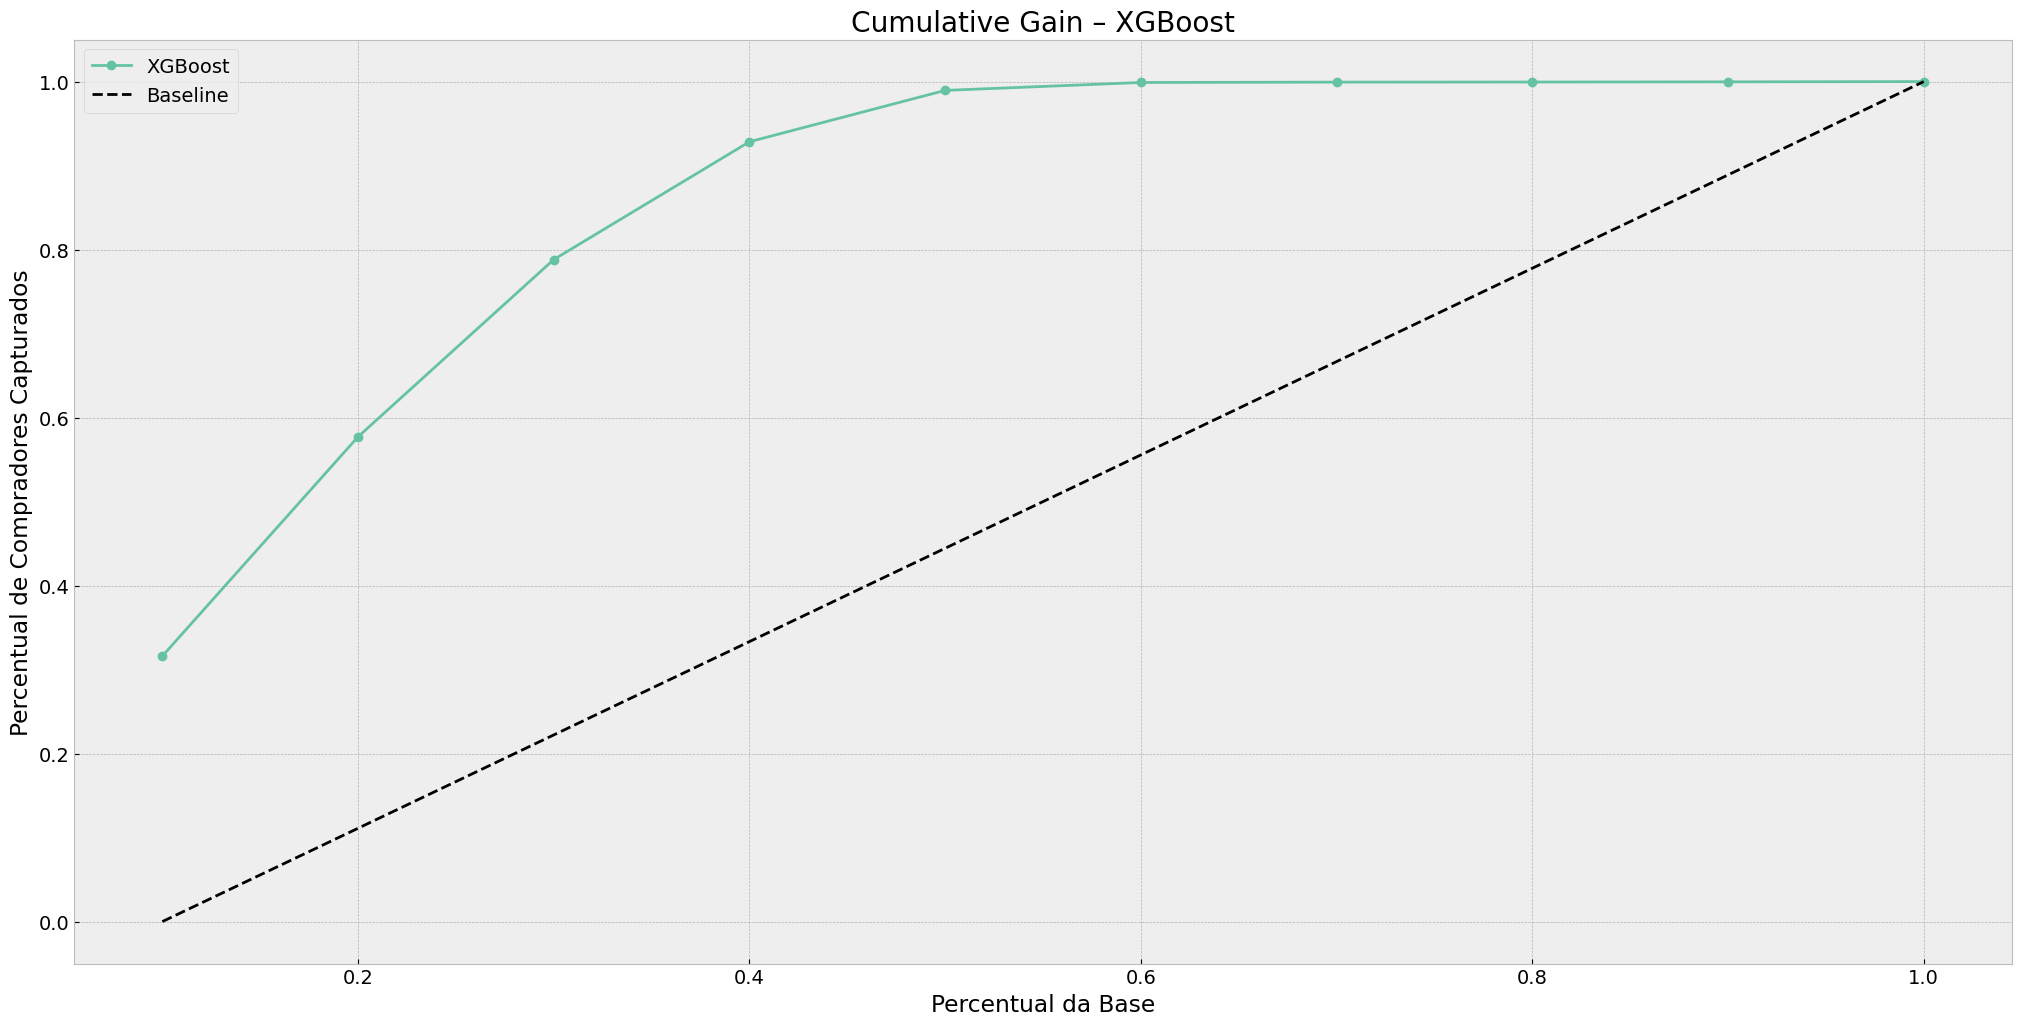

In [ ]:
df_rank_xgb = x_val.copy()
df_rank_xgb['score'] = y_val_xgb
df_rank_xgb['response'] = y_val.values

cg_xgb = cumulative_gain(df_rank_xgb)
x_xgb = get_x_axis(cg_xgb)

plt.plot(x_xgb, cg_xgb.values, marker='o', label='XGBoost')
plt.plot(x_xgb, np.linspace(0, 1, len(cg_xgb)), linestyle='--', color='black', label='Baseline')

plt.title('Cumulative Gain – XGBoost')
plt.xlabel('Percentual da Base')
plt.ylabel('Percentual de Compradores Capturados')
plt.grid(True)
plt.legend()
plt.show()


## 7.4 Comparative Models

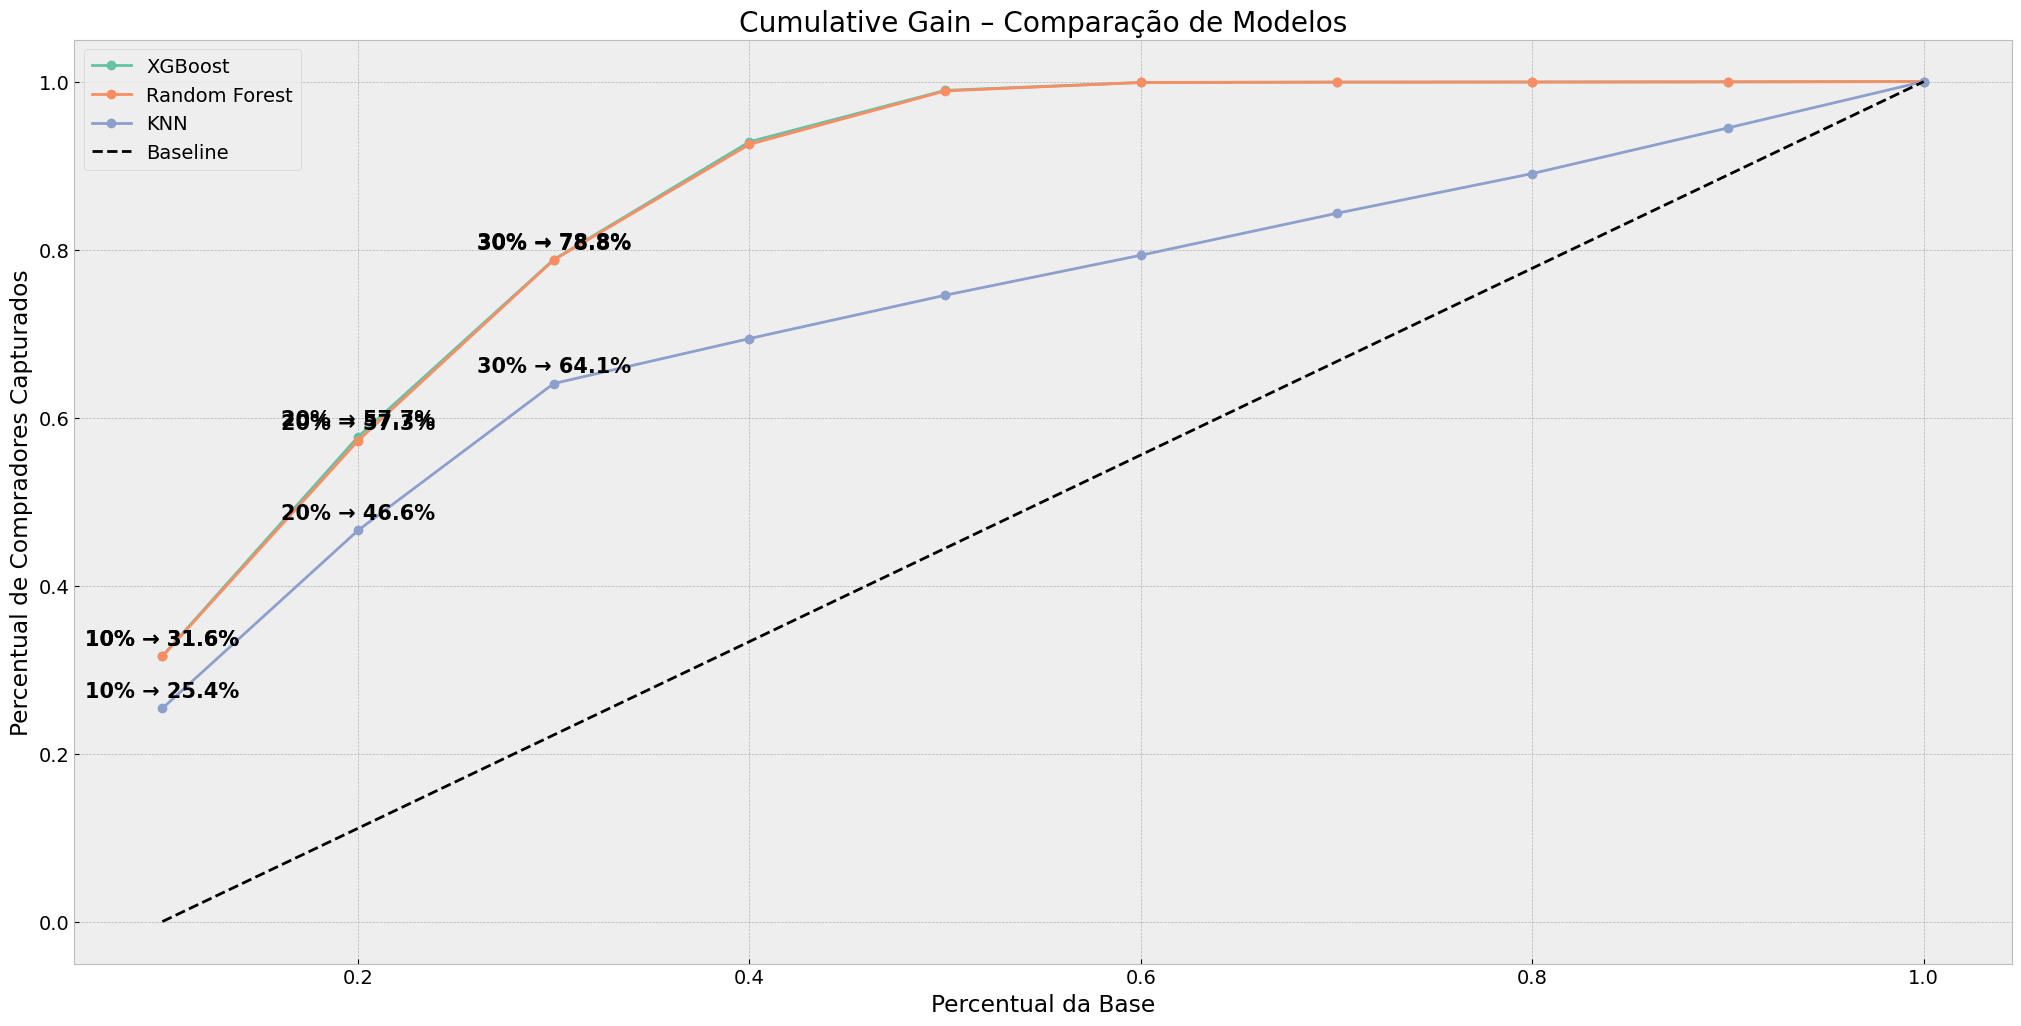

In [ ]:
x_base = get_x_axis(cg_xgb)

fig, ax = plt.subplots()

ax.plot(x_base, cg_xgb.values, marker='o', label='XGBoost')
ax.plot(x_base, cg_rf.values, marker='o', label='Random Forest')
ax.plot(x_base, cg_knn.values, marker='o', label='KNN')

# baseline
ax.plot(
    x_base,
    np.linspace(0, 1, len(x_base)),
    linestyle='--',
    color='black',
    label='Baseline'
)

annotate_points(ax, x_base, cg_xgb)
annotate_points(ax, x_base, cg_rf)
annotate_points(ax, x_base, cg_knn)

ax.set_title('Cumulative Gain – Comparação de Modelos')
ax.set_xlabel('Percentual da Base')
ax.set_ylabel('Percentual de Compradores Capturados')
ax.legend()
ax.grid(True)

plt.show()


# 8 - FINE TUNNING

## 8.2 Optuna/RandomForest

### 8.2.1 Best Parameters

In [ ]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 4, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 20, 200),
        'max_features': trial.suggest_float('max_features', 0.3, 0.9),
        'n_jobs': -1,
        'random_state': 42
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    gains = []

    for train_idx, val_idx in skf.split(x_train, y_train):

        X_tr, X_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = RandomForestClassifier(**params)
        model.fit(X_tr, y_tr)

        y_score = model.predict_proba(X_val)[:, 1]

        df_val = pd.DataFrame({
            'score': y_score,
            'response': y_val.values
        })

        gain_curve = cumulative_gain(
            df_val,
            score_col='score',
            target_col='response',
            n_bins=10
        )

        gains.append(gain_curve.iloc[-1])

    return np.mean(gains)


In [ ]:
#study = optuna.create_study(direction='maximize')

#study.optimize(
#    objective,
#    n_trials=30,     
#    show_progress_bar=True
#)

#study.best_value
#study.best_params


In [ ]:
rf_best_params = {'n_estimators': 392,
            'max_depth': 13,
            'min_samples_leaf': 94,
            'max_features': 0.6839141522291623}

best_value = {0.3190430314707771}

### 8.2.2 Final with parameters

In [ ]:
rf_final = RandomForestClassifier(
    **rf_best_params,
    n_jobs=-1,
    random_state=42
)

rf_final.fit(x_train, y_train)

y_val_score_rf = rf_final.predict_proba(x_val)[:, 1]

df_rank_rf = x_val.copy()
df_rank_rf['score'] = y_val_score_rf
df_rank_rf['response'] = y_val.values


cg_rf_final = cumulative_gain(df_rank_rf)

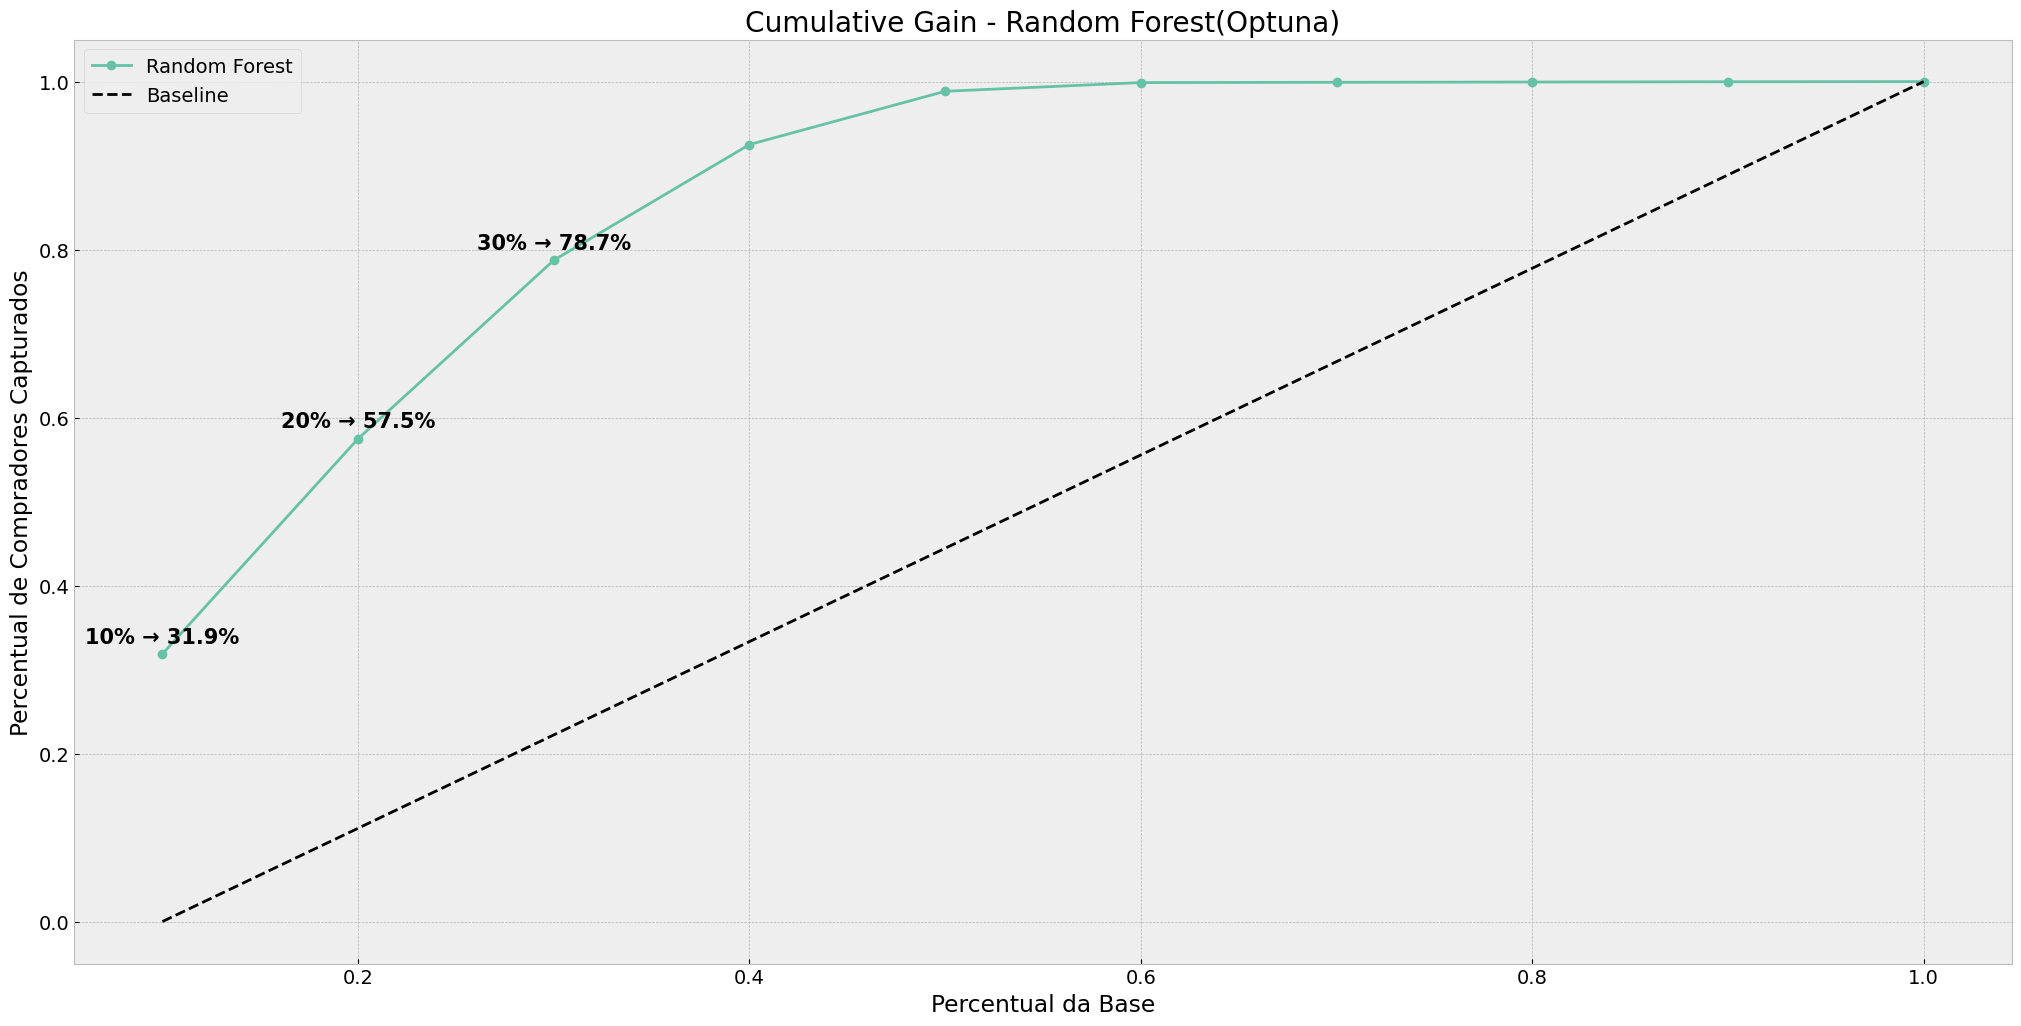

In [ ]:
x_rf = get_x_axis(cg_rf_final)

fig, ax = plt.subplots()

ax.plot(x_rf, cg_rf_final.values, marker='o', label='Random Forest')

ax.plot(
    x_rf,
    np.linspace(0, 1, len(x_rf)),
    linestyle='--',
    color='black',
    label='Baseline'
)

annotate_points(ax, x_rf, cg_rf_final)

ax.set_title('Cumulative Gain - Random Forest(Optuna)')
ax.set_xlabel('Percentual da Base')
ax.set_ylabel('Percentual de Compradores Capturados')
ax.legend()
ax.grid(True)

plt.show()


## 8.3 Optuna/XGBoost

### 8.3.1 Best Parameters

In [ ]:
def objective_xgb(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),

        
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    gains = []

    for train_idx, val_idx in skf.split(x_train, y_train):

        X_tr, X_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr)

        y_score = model.predict_proba(X_val)[:, 1]

        df_val = pd.DataFrame({
            'score': y_score,
            'response': y_val.values
        })

        gain_curve = cumulative_gain(
            df_val,
            score_col='score',
            target_col='response',
            n_bins=10
        )

        gains.append(gain_curve.iloc[-1])

    return np.mean(gains)


In [ ]:
#study_xgb = optuna.create_study(direction='maximize')
#study_xgb.optimize(objective_xgb, n_trials=50)

#study_xgb.best_params
#study_xgb.best_value


In [ ]:
xgb_best_params = {'n_estimators': 473,
 'max_depth': 10,
 'learning_rate': 0.16849213144278608,
 'subsample': 0.9625037474229305,
 'colsample_bytree': 0.9812324988183998,
 'min_child_weight': 37,
 'gamma': 2.370180498709302,
 'reg_alpha': 0.6118690382001313,
 'reg_lambda': 9.20900729046941}

### 8.3.2 Final with Parameters

In [ ]:
xgb_final = XGBClassifier(
    **xgb_best_params,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(x_train, y_train)

y_val_score_xgb = xgb_final.predict_proba(x_val)[:, 1]

df_rank_xgb = x_val.copy()
df_rank_xgb['score'] = y_val_score_xgb
df_rank_xgb['response'] = y_val.values


cg_xgb_final = cumulative_gain(df_rank_xgb)

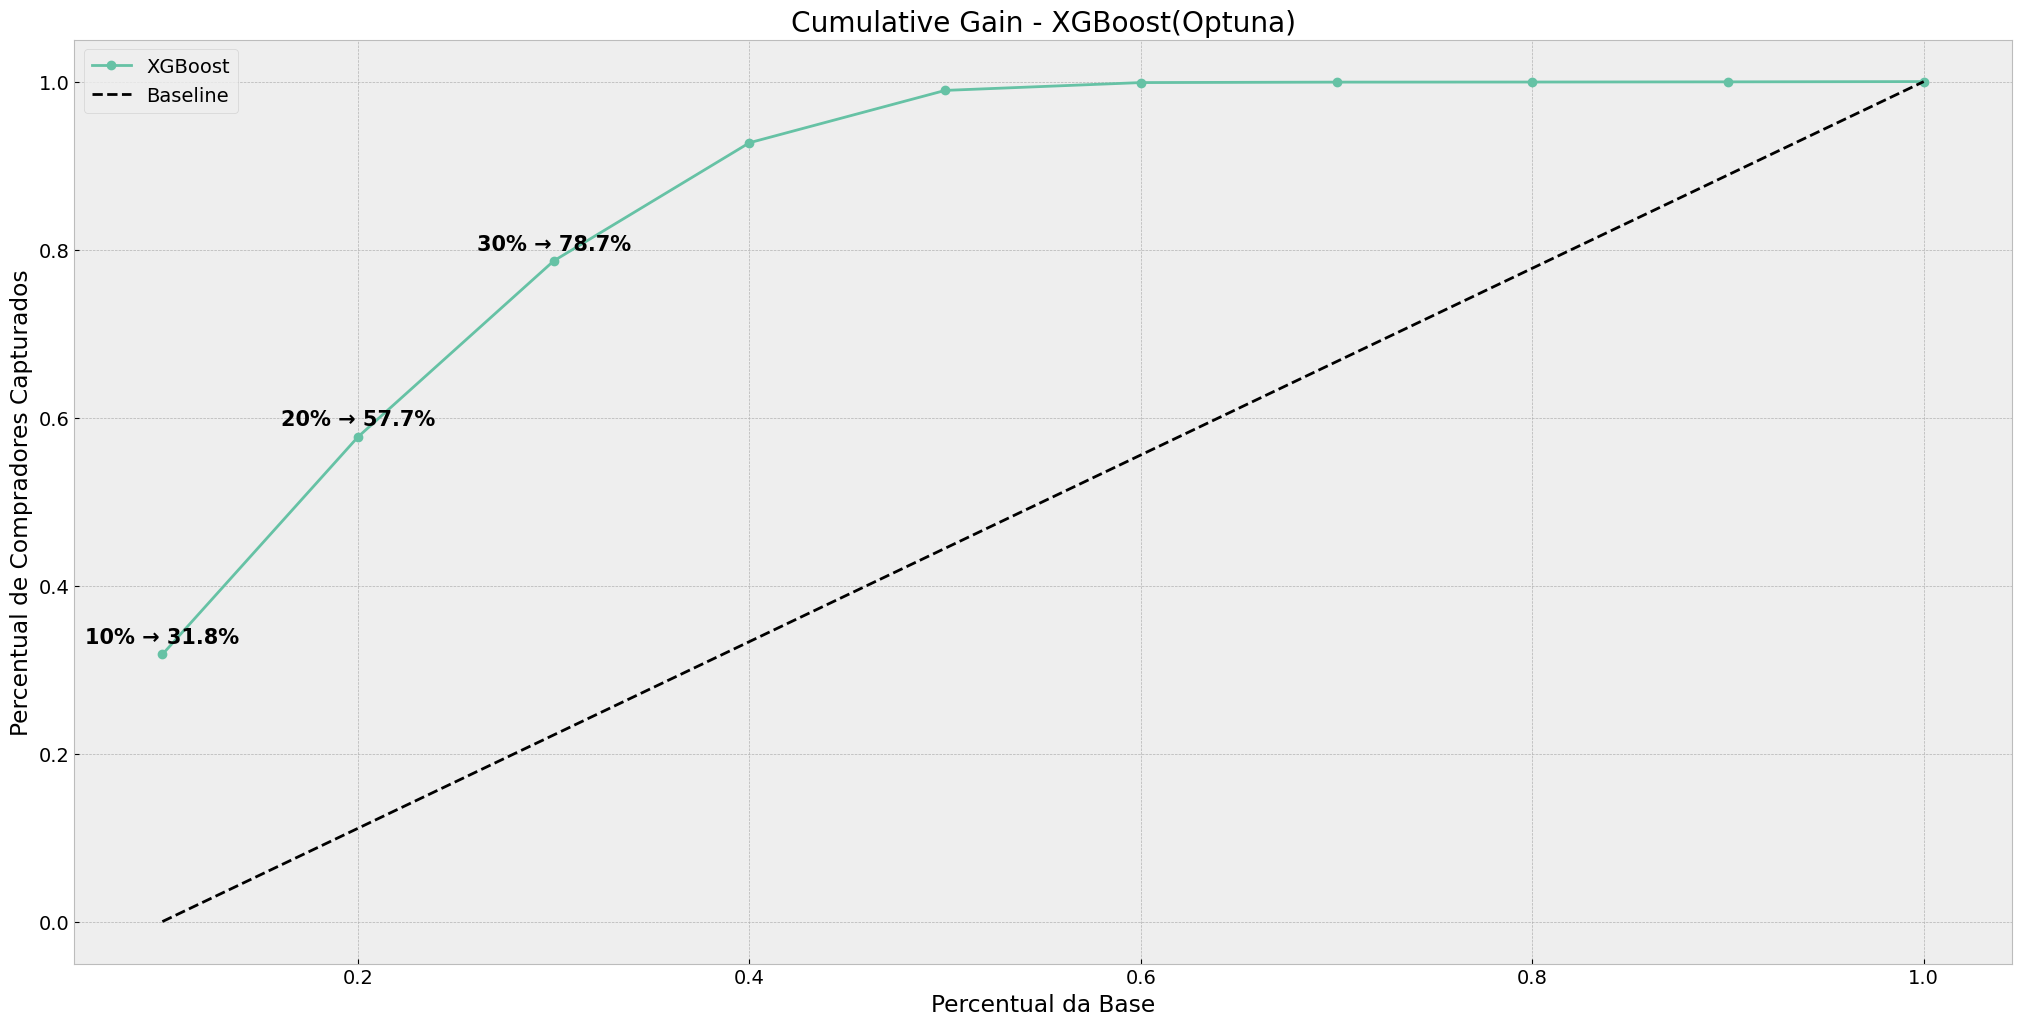

In [ ]:
x_xgb = get_x_axis(cg_xgb_final)

fig, ax = plt.subplots()

ax.plot(x_xgb, cg_xgb_final.values, marker='o', label='XGBoost')

ax.plot(
    x_xgb,
    np.linspace(0, 1, len(x_xgb)),
    linestyle='--',
    color='black',
    label='Baseline'
)

annotate_points(ax, x_xgb, cg_xgb_final)

ax.set_title('Cumulative Gain - XGBoost(Optuna)')
ax.set_xlabel('Percentual da Base')
ax.set_ylabel('Percentual de Compradores Capturados')
ax.legend()
ax.grid(True)

plt.show()


## 8.4 Comparation

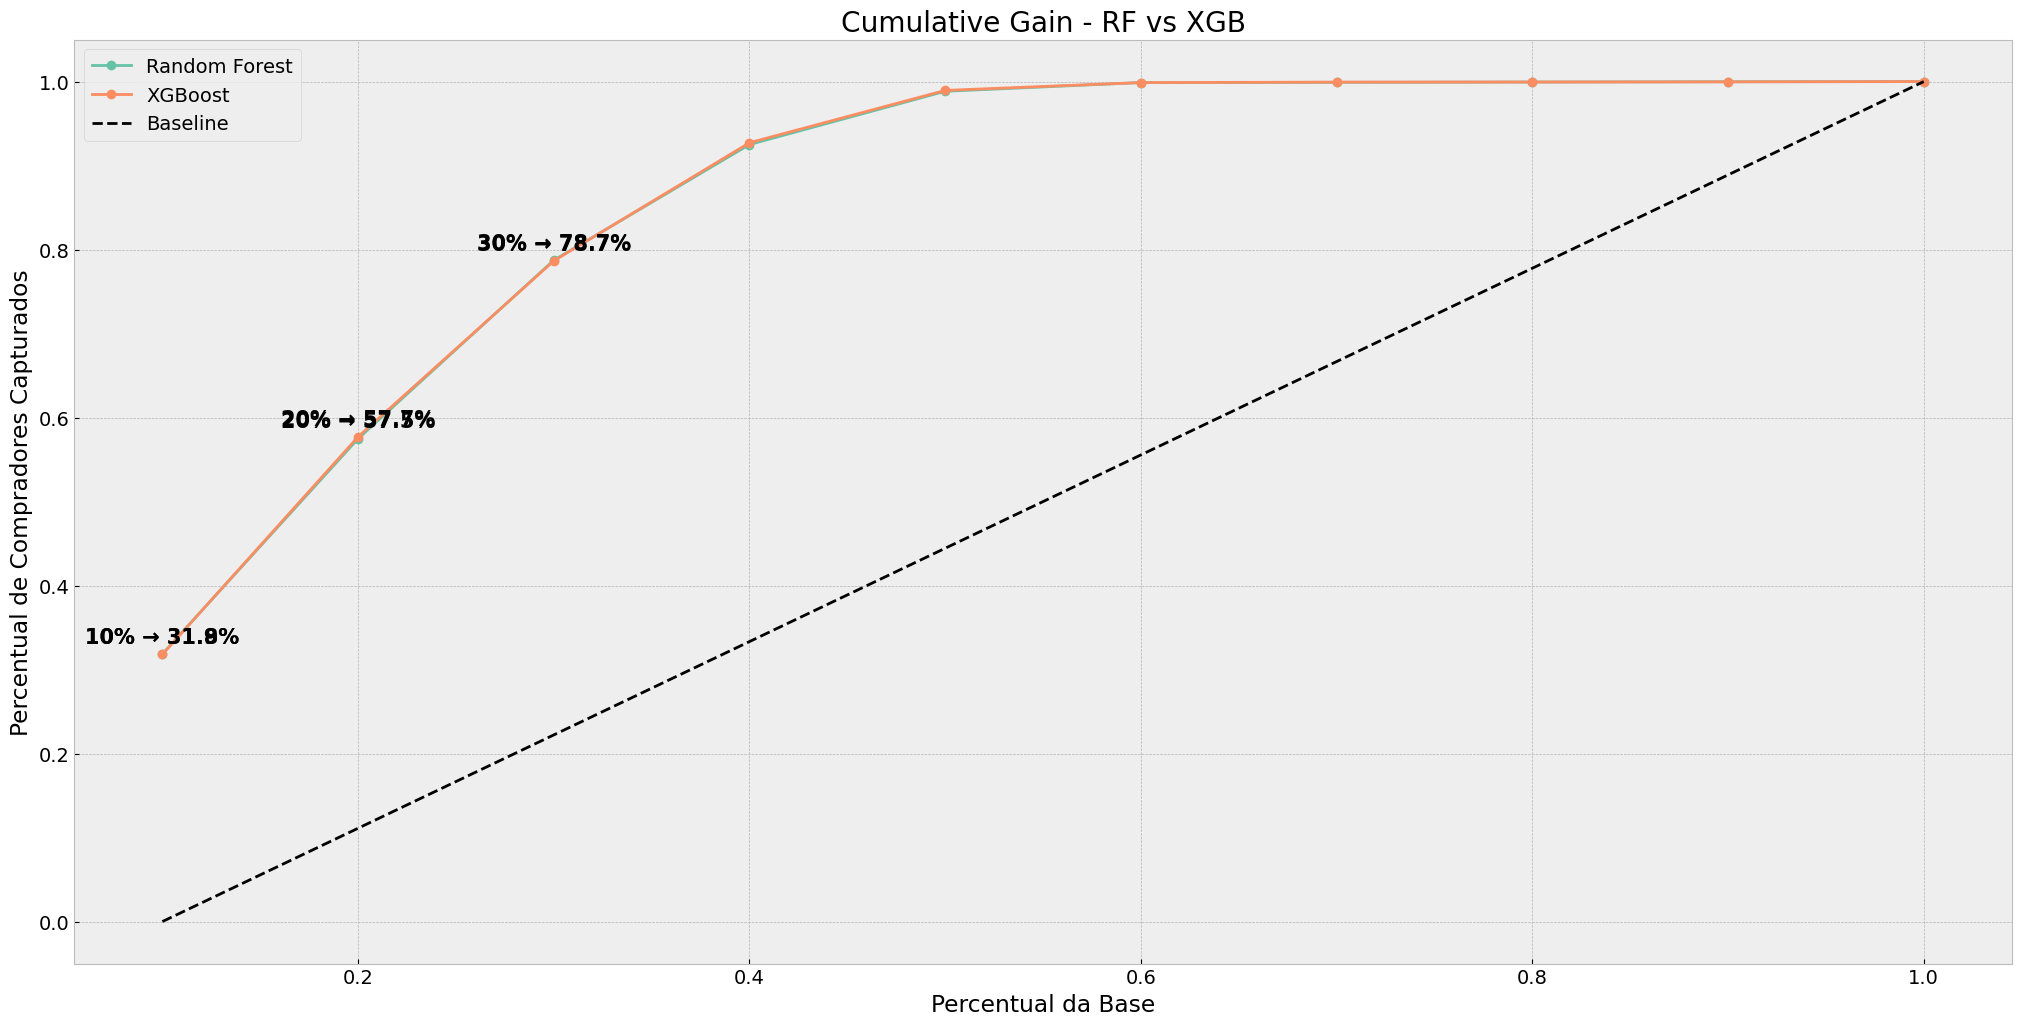

In [ ]:
x_rf = get_x_axis(cg_rf_final)
x_xgb = get_x_axis(cg_xgb_final)

fig, ax = plt.subplots()

ax.plot(x_rf, cg_rf_final.values, marker='o', label='Random Forest')
ax.plot(x_xgb, cg_xgb_final.values, marker='o', label='XGBoost')

ax.plot(
    x_rf,
    np.linspace(0, 1, len(x_rf)),
    linestyle='--',
    color='black',
    label='Baseline'
)

annotate_points(ax, x_rf, cg_rf_final)
annotate_points(ax, x_xgb, cg_xgb_final)

ax.set_xlabel('Percentual da Base')
ax.set_ylabel('Percentual de Compradores Capturados')
ax.set_title('Cumulative Gain - RF vs XGB')
ax.legend()
ax.grid(True)

plt.show()


In [ ]:
from sklearn.metrics import ndcg_score

ndcg_rf_10 = ndcg_score(
    y_val.values.reshape(1, -1),
    y_val_score_rf.reshape(1, -1),
    k=int(0.1 * len(y_val))
)

ndcg_xgb_10 = ndcg_score(
    y_val.values.reshape(1, -1),
    y_val_score_xgb.reshape(1, -1),
    k=int(0.1 * len(y_val))
)

print(f'NDCG@10% RF: {ndcg_rf_10:.4f}')
print(f'NDCG@10% XGB: {ndcg_xgb_10:.4f}')


NDCG@10% RF: 0.3950
NDCG@10% XGB: 0.3944


## 8.5 Model Performance

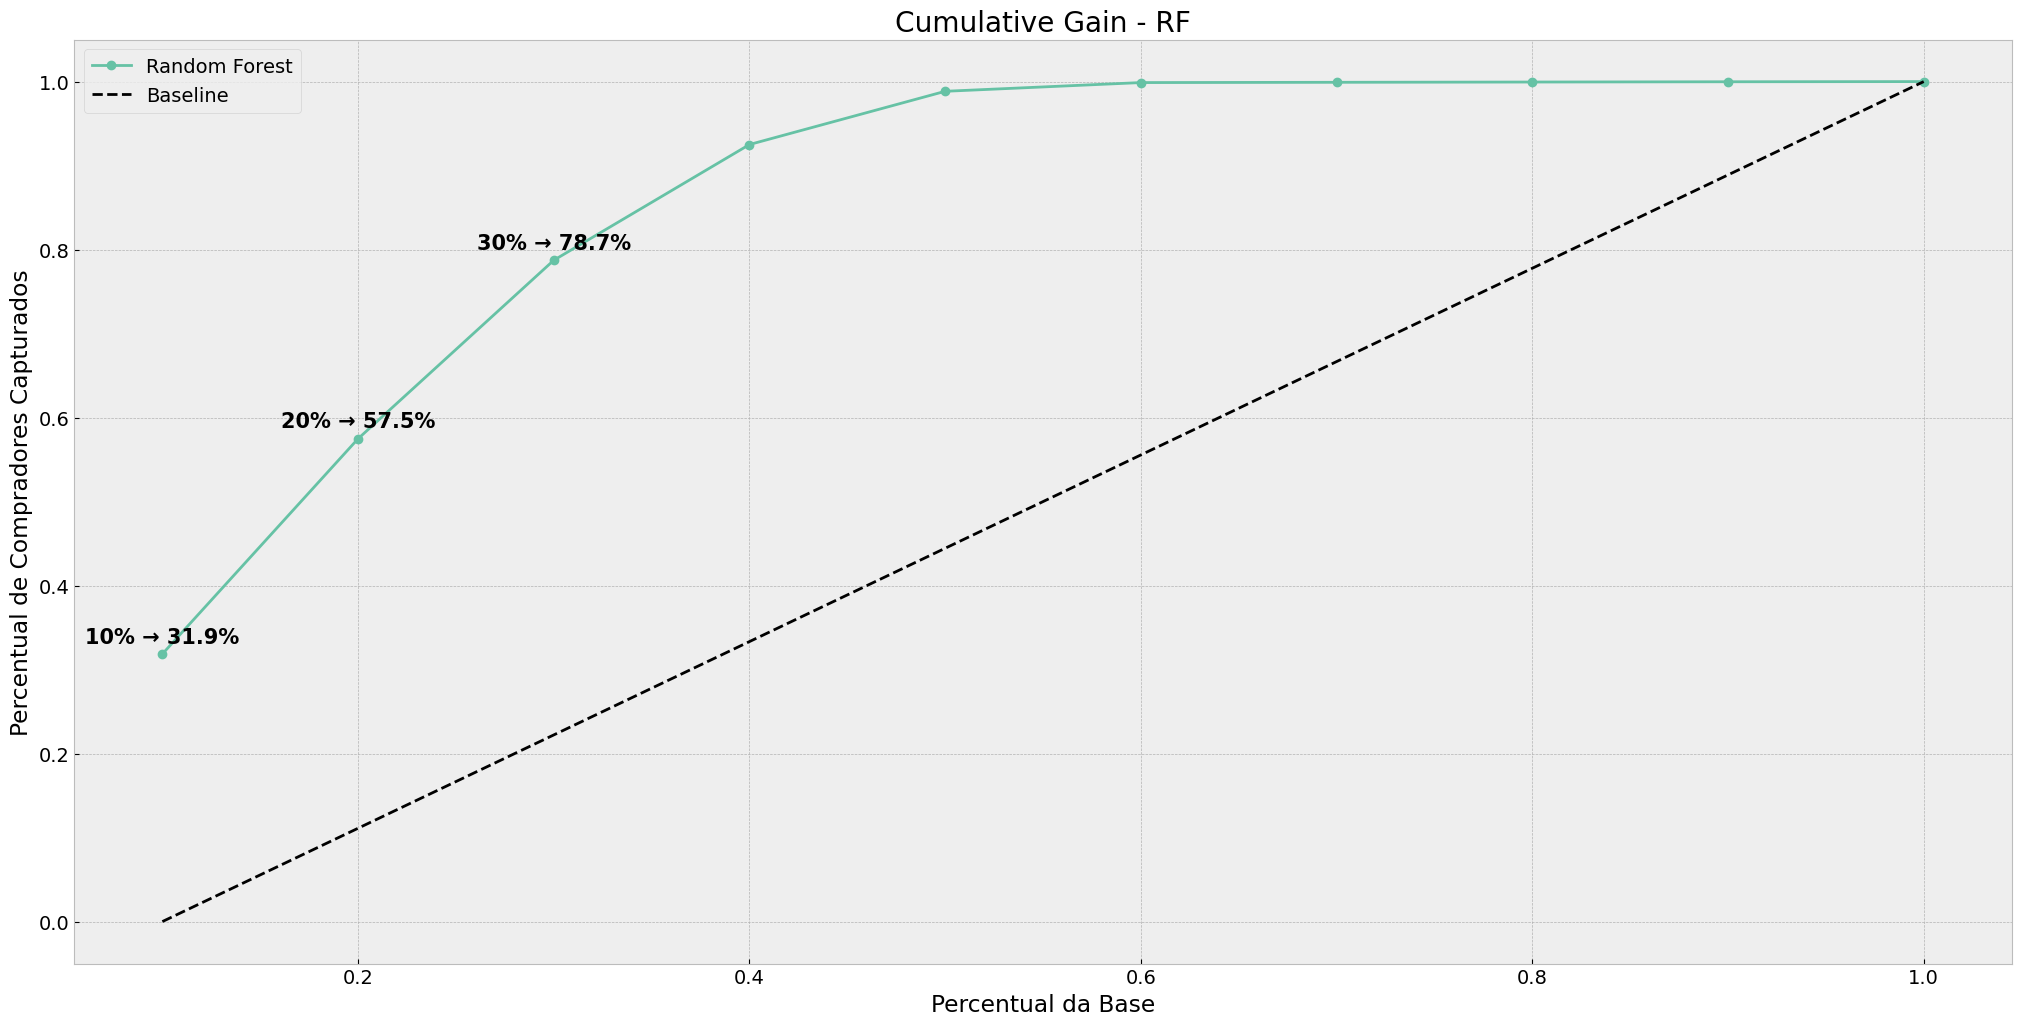

In [ ]:
x_rf = get_x_axis(cg_rf_final)

fig, ax = plt.subplots()

ax.plot(x_rf, cg_rf_final.values, marker='o', label='Random Forest')

ax.plot(
    x_rf,
    np.linspace(0, 1, len(x_rf)),
    linestyle='--',
    color='black',
    label='Baseline'
)

annotate_points(ax, x_rf, cg_rf_final)

ax.set_xlabel('Percentual da Base')
ax.set_ylabel('Percentual de Compradores Capturados')
ax.set_title('Cumulative Gain - RF')
ax.legend()
ax.grid(True)

plt.show()


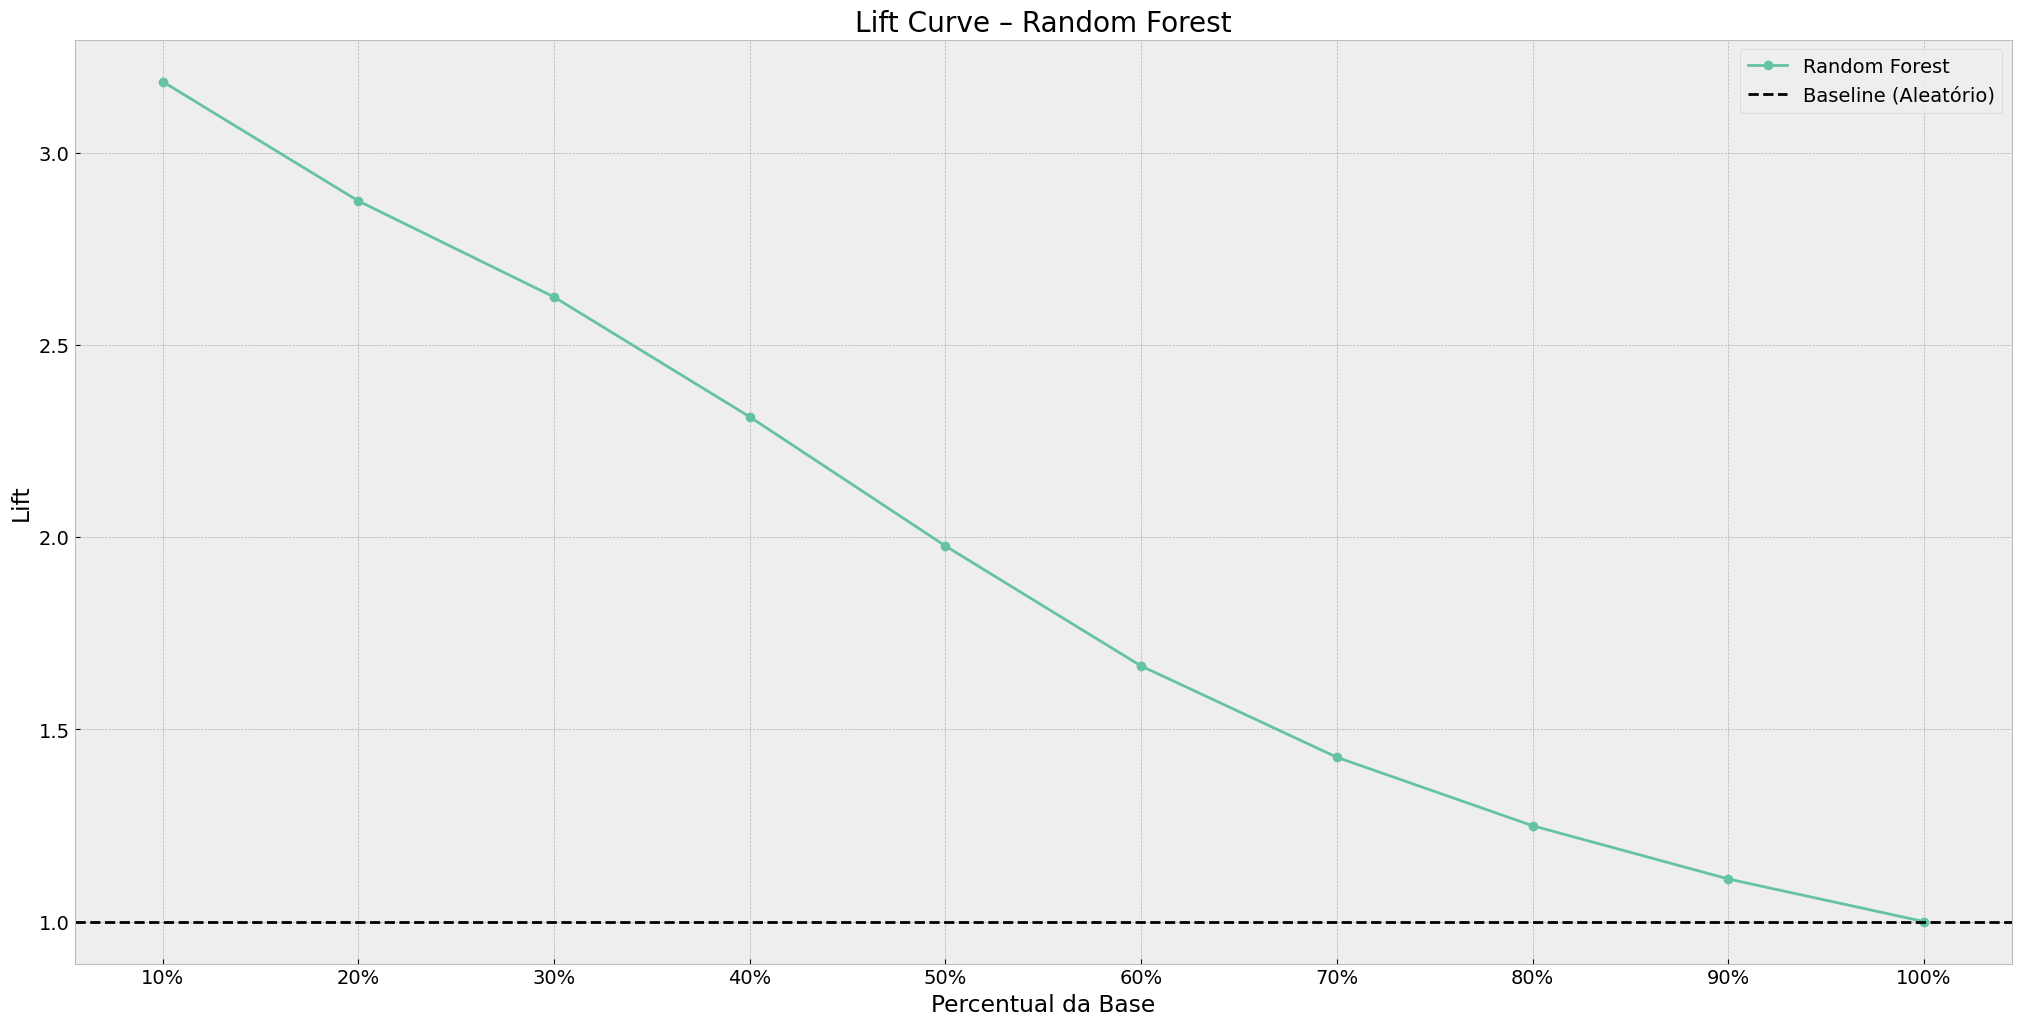

In [ ]:
def lift_curve(y_true, y_score, steps=10):
    df = (
        pd.DataFrame({'y_true': y_true, 'score': y_score})
        .sort_values('score', ascending=False)
        .reset_index(drop=True)
    )

    base_rate = df['y_true'].mean()
    percents = np.linspace(0.1, 1.0, steps)
    lifts = []

    for p in percents:
        cutoff = int(len(df) * p)
        top_rate = df.iloc[:cutoff]['y_true'].mean()
        lifts.append(top_rate / base_rate)

    return percents, np.array(lifts)

# Random Forest
x_rf, lift_rf = lift_curve(
    y_val.values,
    y_val_score_rf,
    steps=10
)

fig, ax = plt.subplots()

ax.plot(x_rf, lift_rf, marker='o', label='Random Forest')

# baseline (lift = 1)
ax.axhline(
    y=1,
    linestyle='--',
    color='black',
    label='Baseline (Aleatório)'
)

ax.set_xticks(x_rf)
ax.set_xticklabels([f'{int(p*100)}%' for p in x_rf])

ax.set_xlabel('Percentual da Base')
ax.set_ylabel('Lift')
ax.set_title('Lift Curve – Random Forest')
ax.legend()
ax.grid(True)

plt.show()


In [ ]:
def precision_at_k(y_true, y_score, k):
    """
    k pode ser:
      - float entre 0 e 1  → percentual da base (ex: 0.1 = 10%)
      - int >= 1           → número absoluto de clientes (ex: 20000)
    """
    df = pd.DataFrame({
        'y_true': y_true,
        'score': y_score
    }).sort_values('score', ascending=False).reset_index(drop=True)

    n = len(df)

    # define cutoff
    if isinstance(k, float):
        if k <= 0 or k > 1:
            raise ValueError("Se k for float, deve estar entre 0 e 1 (ex: 0.1 = 10%)")
        cutoff = int(n * k)

    elif isinstance(k, int):
        if k <= 0 or k > n:
            raise ValueError(f"Se k for int, deve estar entre 1 e {n}")
        cutoff = k

    else:
        raise ValueError("k deve ser float (percentual) ou int (quantidade absoluta)")

    return df.iloc[:cutoff]['y_true'].mean()


p20k_rf = precision_at_k(y_val.values, y_val_score_rf, k=0.1)
print(f'RF Precision@10%: {p20k_rf:.3f} good leads')


RF Precision@10%: 0.390 good leads



📌 TABELA FINAL DE DECISÃO – RANDOM FOREST



,Cutoff (%),Clientes Abordados,Precision@K,Lift@K,Ganho Acumulado
0,10%,7622,0.390,3.18,0.318
1,20%,15244,0.352,2.87,0.575
2,30%,22866,0.322,2.62,0.787


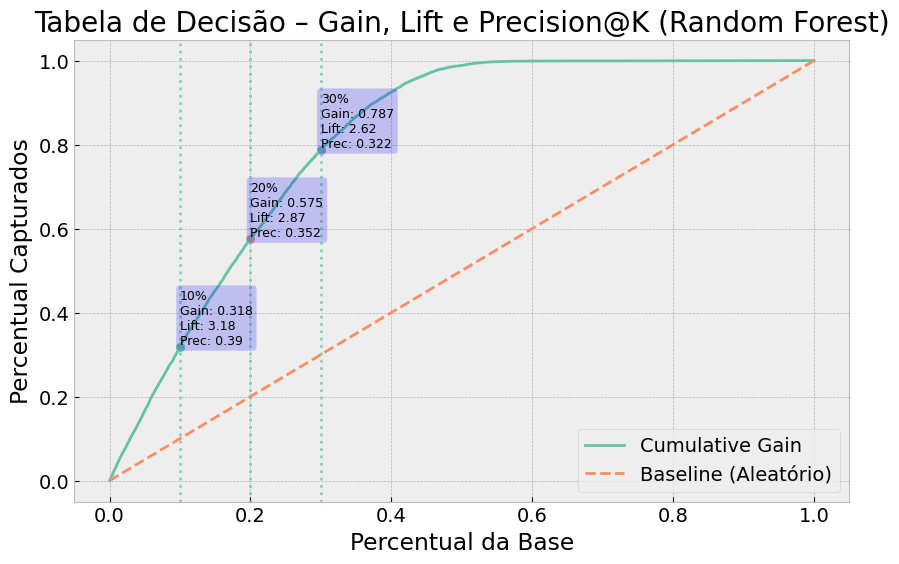

In [ ]:
# ===============================
# INPUTS DO SEU PROJETO
# ===============================
y_true = y_val.values
y_score = y_val_score_rf

ks = [0.10, 0.20, 0.30]

# ===============================
# BASE ORGANIZADA
# ===============================
df = (
    pd.DataFrame({'y_true': y_true, 'score': y_score})
    .sort_values('score', ascending=False)
    .reset_index(drop=True)
)

n = len(df)
total_positives = df['y_true'].sum()
base_rate = df['y_true'].mean()

df['cum_response'] = df['y_true'].cumsum()
df['cum_gain'] = df['cum_response'] / total_positives
df['population_pct'] = (np.arange(n) + 1) / n

# ===============================
# TABELA FINAL DE DECISÃO
# ===============================
rows = []

for k in ks:
    cutoff = int(n * k)

    precision = df.iloc[:cutoff]['y_true'].mean()
    lift = precision / base_rate
    gain = df.iloc[:cutoff]['cum_gain'].iloc[-1]

    rows.append({
        'Cutoff (%)': f"{int(k*100)}%",
        'Clientes Abordados': cutoff,
        'Precision@K': round(precision, 3),
        'Lift@K': round(lift, 2),
        'Ganho Acumulado': round(gain, 3)
    })

decision_table = pd.DataFrame(rows)

print("\n📌 TABELA FINAL DE DECISÃO – RANDOM FOREST\n")
display(decision_table)

# ===============================
# PLOT FINAL DE DECISÃO
# ===============================
fig, ax = plt.subplots(figsize=(10, 6))

# Curva de ganho
ax.plot(df['population_pct'], df['cum_gain'], label='Cumulative Gain', linewidth=2)
ax.plot([0, 1], [0, 1], '--', label='Baseline (Aleatório)')

# Marcação dos cutoffs
for _, row in decision_table.iterrows():
    k_pct = int(row['Cutoff (%)'].replace('%','')) / 100
    cutoff = int(n * k_pct)
    gain = row['Ganho Acumulado']

    ax.axvline(k_pct, linestyle=':', alpha=0.7)
    ax.scatter(k_pct, gain)

    ax.text(
        k_pct,
        gain,
        f"{row['Cutoff (%)']}\nGain: {gain}\nLift: {row['Lift@K']}\nPrec: {row['Precision@K']}",
        ha='left',
        va='bottom',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', alpha=0.2)
    )

ax.set_xlabel('Percentual da Base')
ax.set_ylabel('Percentual Capturados')
ax.set_title('Tabela de Decisão – Gain, Lift e Precision@K (Random Forest)')
ax.legend()
ax.grid(True)

plt.show()
